In [2]:
import matplotlib.pyplot as plt #viz #GUI manager
import seaborn as sns #viz #plotly is another package
import datetime
import pandas as pd
import numpy as np
from pandas import Grouper #groupby
#statistical data exploration, conducting statistical tests, and estimation of different statistical models
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf #autocorrelation plot
from statsmodels.tsa.api import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing # double and triple exponential smoothing
from pandas.plotting import autocorrelation_plot #autocorrelation plot
from statsmodels.graphics.gofplots import qqplot #residual diagnostics
from sklearn.metrics import mean_squared_error #accuracy metrics
from math import sqrt
from sklearn.metrics import mean_absolute_error #accuracy metrics

from random import gauss #create gaussian white noise
from random import seed
from pandas import Series

from statsmodels.tsa.stattools import adfuller # Augmented Dickey Fuller test for testing stationarity

from statsmodels.tsa.arima_model import ARIMA #for manual ARIMA

import pmdarima as pm #auto arima
import scipy.io as sio
import os


## Load the intrinsic timescale time series

In [3]:
data_folder = '/Users/jiangruitong/Library/CloudStorage/GoogleDrive-ruitongj@andrew.cmu.edu/Shared drives/NML_shared/PapersInPrep/Journals/Larry/Temporal Correlations and Performance Fluctuation'

alpha = pd.read_csv(os.path.join(data_folder, 'timescale_alpha.csv'),parse_dates=['Time'], index_col='Time')
beta = pd.read_csv(os.path.join(data_folder, 'timescale_beta.csv'),parse_dates=['Time'], index_col='Time')
delta = pd.read_csv(os.path.join(data_folder, 'timescale_delta.csv'),parse_dates=['Time'], index_col='Time')
theta = pd.read_csv(os.path.join(data_folder, 'timescale_theta.csv'),parse_dates=['Time'], index_col='Time')

In [4]:
alpha.shape

(34524, 3)

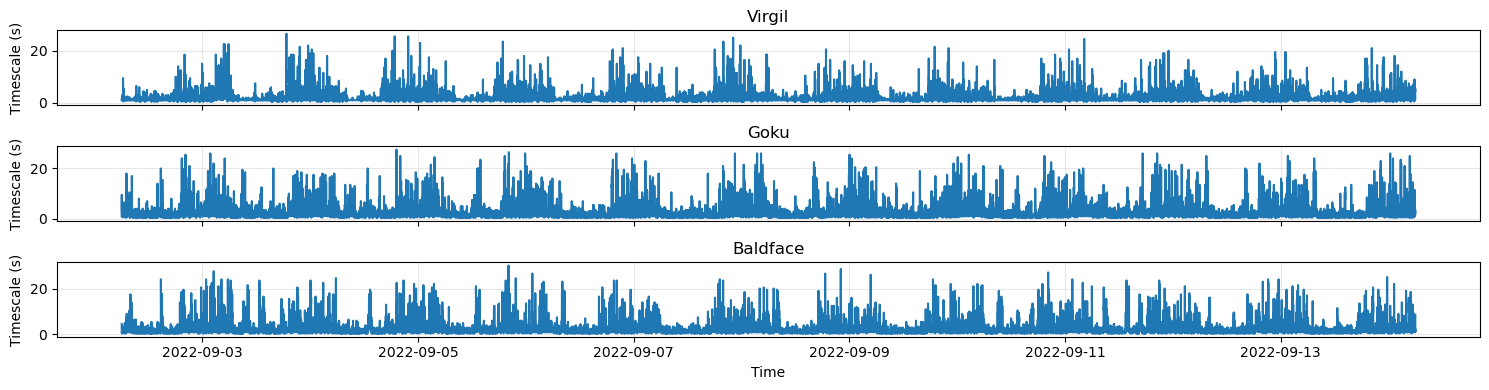

In [5]:
def plot_subject_subplots(df, subject_cols=None, figsize=(15, 4)):
    if subject_cols is None:
        subject_cols = df.columns.tolist()
    
    if len(subject_cols) != 3:
        raise ValueError("Please provide exactly 3 subject columns for plotting.")
    
    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)
    for ax, subj in zip(axes, subject_cols):
        ax.plot(df.index, df[subj])
        ax.set_title(subj)
        ax.set_ylabel("Timescale (s)")
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel("Time")
    plt.tight_layout()
    return fig, axes

fig,axes = plot_subject_subplots(alpha)


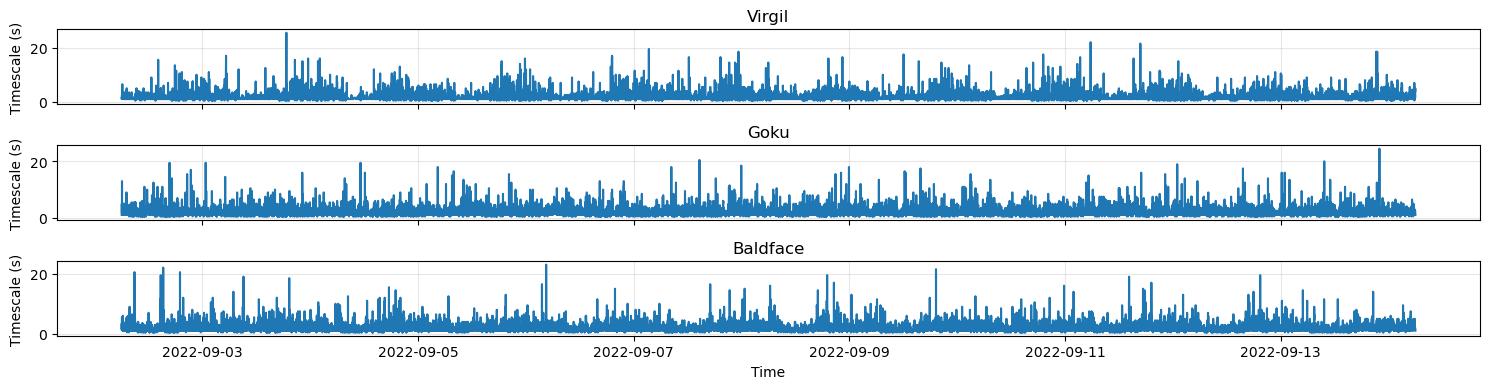

In [6]:
fig,axes = plot_subject_subplots(beta)

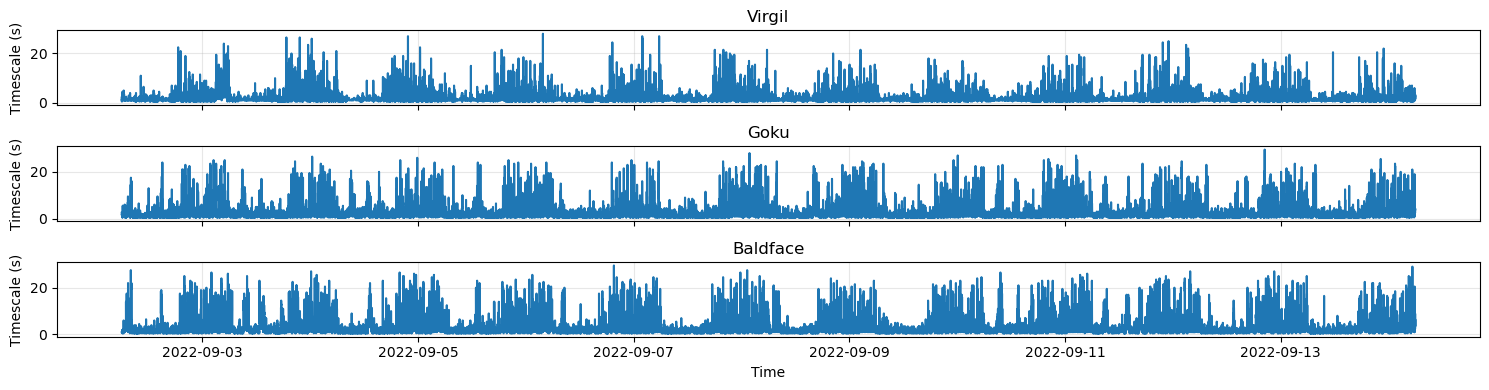

In [7]:
fig,axes = plot_subject_subplots(theta)

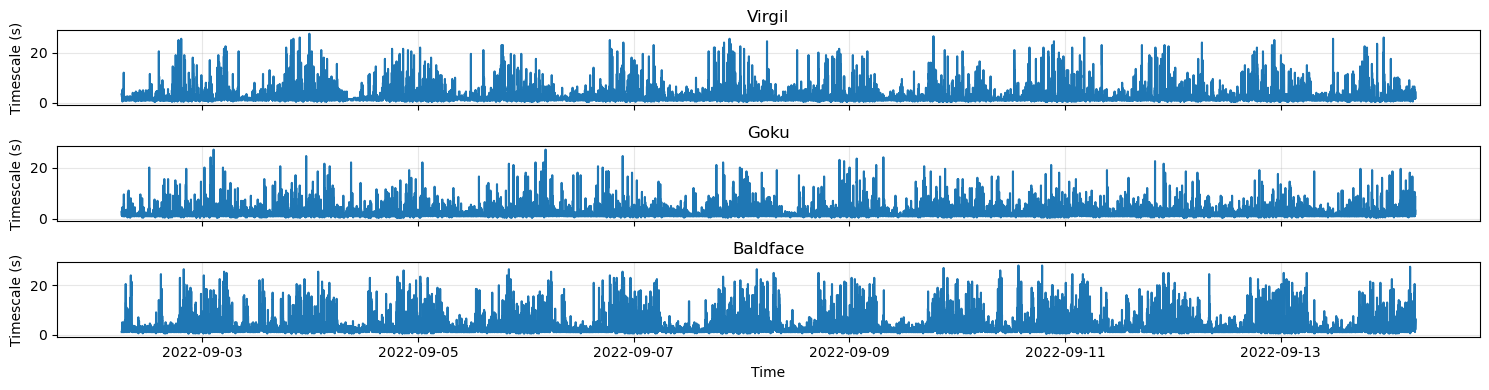

In [8]:
fig,axes = plot_subject_subplots(delta)

## Inspect the regime/state to decide what model to use to model the volatility

In [9]:
from scipy import stats
from scipy.optimize import minimize_scalar
from scipy.signal import argrelmin
def threshold_mixture(x,n_components=2,n_iter = 200, tol=1e-6):
    """
    input: x (values), n_components (number of mixture components), n_iter(max EM iterations), tol:float (convergence threshold)

    returns: threshold (value where P(burst component)=0.5), params(fitted parameters include weights, shapes, scales for each component)
    """
    x= np.asarray(x,dtype=float)
    x = x[x>0]
    n = len(x)
    k=n_components
    # Initialize parameters
    sorted_x = np.sort(x)
    split = np.array_split(sorted_x, k)
    shapes = np.array([np.mean(s)**2/np.var(s) for s in split])
    scales = np.array([np.var(s)/np.mean(s) for s in split])
    weights = np.ones(k)/k
    ll_prev = -np.inf
    for iteration in range(n_iter):
        resp = np.zeros((n,k))
        for j in range(k):
            resp[:,j]=weights[j]*stats.gamma.pdf(x, a=shapes[j], scale=scales[j])
        resp_sum = resp.sum(axis=1,keepdims=True)
        resp_sum = np.maximum(resp_sum,1e-10)
        resp /= resp_sum
    
         # calculate the log-likelihood
        ll = np.sum(np.log(np.maximum(resp_sum.ravel(),1e-300)))
        if abs(ll-ll_prev)<tol:
            break
        ll_prev = ll
        # M-step: update parameters
        nk = resp.sum(axis=0)
        weights = nk/n
        for j in range(k):
            r = resp[:,j]
            mean_j = np.sum(r*x)/nk[j]
            var_j = np.sum(r*(x-mean_j)**2)/nk[j]
            var_j = max(var_j,1e-10)
            shapes[j] = mean_j**2/var_j
            scales[j]=var_j/mean_j
    # Order components by mean (floor first, burst second)
    means = shapes*scales
    order = np.argsort(means)
    shapes = shapes[order]
    scales = scales[order]
    weights = weights[order]
    # Find threshold where P(burst)=0.5
    def diff_posterior(t):
        p0 = weights[0]*stats.gamma.pdf(t, a=shapes[0], scale=scales[0])
        p1 = weights[1]*stats.gamma.pdf(t, a=shapes[1], scale=scales[1])
        return (p1-p0)**2
    result = minimize_scalar(diff_posterior,
                             bounds=(means[0],means[1]),
                             method='bounded')
    threshold = result.x
    params = {
        'weights': weights,
        'shapes': shapes,
        'scales': scales,
        'means':means[order],
        'converged_iter':iteration,
        'log_likelihood':ll
    }
    return threshold, params
def threshold_otsu(x,n_bins=256):
    """ 
    find threshold that maximizes between-class variance
    input: x (values), n_bins (number of histogram bins)

    output: threshold(float), sigma_b_max(float)
    """
    x = np.asarray(x,dtype=float)
    counts, bin_edges = np.histogram(x, bins=n_bins)
    bin_centers = (bin_edges[:-1]+bin_edges[1:])/2
    counts = counts.astype(float)
    total = counts.sum()

    # Sweep all possible thresholds
    best_threshold = bin_centers[0]
    sigma_b_max = 0
    
    w0_cumulative = 0
    mu0_cumulative = 0
    mu_total = np.sum(counts*bin_centers)
    for i in range(len(bin_centers)):
        w0_cumulative += counts[i]
        if w0_cumulative==0:
            continue
        w1_cumulative = total - w0_cumulative
        if w1_cumulative==0:
            break
        mu0_cumulative += counts[i]*bin_centers[i]
        mu0 = mu0_cumulative/w0_cumulative
        mu1 = (mu_total - mu0_cumulative)/w1_cumulative
        sigma_b = (w0_cumulative/total)*(w1_cumulative/total)*(mu0-mu1)**2
        if sigma_b > sigma_b_max:
            sigma_b_max = sigma_b
            best_threshold = bin_centers[i]
    return best_threshold, sigma_b_max

def threshold_kde_antimode(x,bw='scott',n_grid=2048):
    """
    find local minimum in the density between the two modes
    input: x, bandwidth method for KDE, number of grid points for evaluation

    output: threshold (location of the antimode), kde (fitted kde object)
    density: density values on grid
    """
    x = np.asarray(x,dtype=float)
    kde=stats.gaussian_kde(x, bw_method=bw)
    grid = np.linspace(x.min(),np.percentile(x,99),n_grid)
    density = kde(grid)

    # get local minima 
    local_min_idx, = argrelmin(density,order=20)

    if len(local_min_idx)==0:
        region = (grid>np.median(x))&(grid<np.percentile(x,90))
        if region.any():
            sub_density = density[region]
            sub_grid = grid[region]
            min_idx = np.argmin(sub_density)
            threshold = sub_grid[min_idx]
        else:
            threshold = np.median(x)
    else:
        candidates=grid[local_min_idx]
        above_median = candidates[candidates>np.median(x)]
        if len(above_median)>0:
            threshold=above_median[0]
        else:
            threshold = candidates[0]
    return threshold, kde, grid, density
def find_threshold(x,method='all',verbose=True):
    """
    wrapper to run one or all threshold methods
    input: x (values), method ('mixture','otsu','kde','all'), verbose (whether to print results or not)
    """
    x=np.asarray(x,dtype=float)
    x=x[~np.isnan(x)]
    results = {}

    if method in ('mixture','all'):
        thresh,params = threshold_mixture(x)
        results['mixture']={'threshold':thresh,'params':params}

    if method in ('otsu','all'):
        thresh,sigma_b = threshold_otsu(x)
        results['otsu']={'threshold':thresh,'sigma_b':sigma_b}
    
    if method in ('kde','all'):
        thresh,kde,grid,density = threshold_kde_antimode(x)
        results['kde']={'threshold':thresh,'kde':kde,'grid':grid,'density':density}
    
    if verbose:
        print(f"\n Threshold estimates (n={len(x)}):")
        print(f" {'Method':<12} {'Threshold':>10}")
        print(f" {'-'*24}")
        for name, res in results.items():
            print(f" {name:<12} {res['threshold']:>10.2f}")

        if len(results)>1:
            thresholds=[r['threshold'] for r in results.values()]
            print(f"\n Range:{min(thresholds):.2f} - {max(thresholds):.2f}")
            print(f" Mean:{np.mean(thresholds):.2f}")
    return results

# Function for visualizing the diurnal differences of the TC values
def tc_day_night_distribution(df,light_on=6,light_off=19,max_tc=20,figsize=(14,12)):
    """
    input:
    df: time table with each column representing the TC associating with a subject
    light_on: hour of the day when light turns on (default 6 for 6am)
    light_off: hour of the day when light turns off (default 19 for 7pm)
    max_tc: float
    figsize:tuple

    return:
    fig: matplotlib.figure.Figure
    summary:pd.DataFrame (per-subject,per-regime summary statistics)
    """
    hour = df.index.hour
    is_day = (hour>=light_on) & (hour<light_off)
    subjects = df.columns.tolist()
    n_subj=len(subjects)
    fig,axes = plt.subplots(n_subj,3,figsize=figsize)
    if n_subj==1:
        axes = axes[np.newaxis,:]
    
    records = []
    for i,subj in enumerate(subjects):
        vals = df[subj].dropna()
        day =vals[is_day]
        night = vals[~is_day]
        u_stat,u_p = stats.mannwhitneyu(day,night,alternative='two-sided')
        ks_stat,ks_p = stats.ks_2samp(day,night)
        for regime, x in [('day',day),('night',night)]:
            records.append({
                'subject':subj,
                'regime':regime,
                'n':len(x),
                'mean':x.mean(),
                'std':x.std(),
                'median':x.median(),
                'iqr':x.quantile(0.75)-x.quantile(0.25),
                'cv':x.std()/x.mean(),
                'max':x.max(),
                'mann_whitney_p':u_p,
                'ks_p':ks_p,
                'night_day_ratio':night.mean()/day.mean()
            })
        # Col 1: distribution overlay
        ax = axes[i,0]
        bins = np.arange(0,vals.max()+0.5,0.5)
        ax.hist(day,bins = bins,density=True,alpha=0.5,color='orange',label='day')
        ax.hist(night,bins = bins,density=True,alpha=0.5,color='navy',label='night')
        ax.set_xlabel('TC(s)')
        ax.set_ylabel('Density')
        ax.set_title(f"{subj}-Distribution")
        ax.legend()
        ax.set_xlim(0,max_tc)
        # Col 2: hourly mean with std error shade
        ax = axes[i,1]
        hourly = vals.groupby(vals.index.hour)
        h_mean = hourly.mean()
        h_std = hourly.std()
        ax.fill_between(h_mean.index,h_mean-h_std,h_mean+h_std,alpha=0.3,color='steelblue')
        ax.plot(h_mean.index,h_mean,'o-',color='steelblue',linewidth=2)
        ax.axvspan(0,light_on,color='gray',alpha=0.2)
        ax.axvspan(light_off,24,color='gray',alpha=0.2)
        ax.set_xlabel('Hour of Day')
        ax.set_ylabel('Mean TC(s)')
        ax.set_title(f"{subj}-Hourly Mean +/- Std")
        ax.set_xticks(range(0,24,3))
        # Col 3: volatility (CV and IQR)
        ax = axes[i,2]
        h_cv = h_std/h_mean
        h_iqr = hourly.quantile(0.75)-hourly.quantile(0.25)
        ax2 = ax.twinx()
        ax.bar(h_cv.index,h_cv,color='coral',alpha=0.6,label='CV')
        ax2.plot(h_iqr.index,h_iqr,'s-',color='darkgreen',linewidth=2,label='IQR')
        ax.axvspan(0,light_on,alpha=0.1,color='gray')
        ax.axvspan(light_off,24,alpha=0.1,color='gray')
        ax.set_xlabel('Hour of Day')
        ax.set_ylabel('CV',color='coral')
        ax2.set_ylabel('IQR (s)',color='darkgreen')
        ax.set_title(f'{subj}-Volatility by hour')
        ax.set_xticks(range(0,24,3))
    plt.tight_layout()
    summary = pd.DataFrame(records).set_index(['subject','regime'])
    return fig, summary

def tc_hourly_volatility(df,light_on=6,light_off=19):
    subjects = df.columns.tolist()
    records = []
    for subj in subjects:
        vals = df[subj].dropna()
        for h in range(24):
            x=vals[vals.index.hour==h]
            if len(x)==0:
                continue
            records.append({
                'subject':subj,
                'hour':h,
                'is_light':(h>=light_on) & (h<light_off),
                'n':len(x),
                'mean':x.mean(),
                'std':x.std(),
                'median':x.median(),
                'iqr':x.quantile(0.75)-x.quantile(0.25),
                'cv':x.std()/x.mean(),
                'skew':x.skew(),
                'kurtosis':x.kurtosis(),
                'max':x.max()
            })
    hourly = pd.DataFrame(records).set_index(['subject','hour'])
    return hourly

def plot_mixture_fit(x,subj_name='',n_components=2,figsize=(10,5)):
    x=np.asarray(x,dtype=float)
    x=x[~np.isnan(x)]
    threshold,params = threshold_mixture(x,n_components=n_components)
    fig,ax = plt.subplots(figsize=figsize)
    bins = np.arange(0,np.percentile(x,99)+0.5,0.5)
    ax.hist(x,bins=bins,density=True,alpha=0.4,color='gray',label='Data')
    grid = np.linspace(0.01,np.percentile(x,99),500)
    colors = ['steelblue','firebrick','forestgreen']
    total_pdf = np.zeros_like(grid)
    for j in range(n_components):
        comp_pdf = (params['weights'][j]*
                    stats.gamma.pdf(grid,a=params['shapes'][j],
                                    scale=params['scales'][j]))
        total_pdf += comp_pdf
        label = (f"Component {j+1}: weight={params['weights'][j]:.2f}, "
                 f"mean={params['means'][j]:.2f}, ")
        ax.plot(grid,comp_pdf,color=colors[j%len(colors)],linewidth=2,label=label)
    ax.plot(grid,total_pdf,'k--',linewidth=1.5,label='Mixture total')
    ax.axvline(threshold,color='red',linestyle=':',linewidth=2,
               label=f'Crossover= {threshold:.2f}')
    ax.set_xlabel('TC (s)',fontsize=14)
    ax.set_ylabel('Density',fontsize=14)
    ax.set_title(f'{subj_name} - Gamma Mixture Fit' if subj_name
                 else 'Gamma mixture fit',fontsize=16)
    ax.legend(fontsize=10)
    ax.set_xlim(0,np.percentile(x,99))
    plt.tight_layout()
    return fig, threshold, params





Check alpha

                     n      mean       std  median  iqr        cv   max  \
subject  regime                                                           
Virgil   day     18696  1.580258  1.350628     1.0  0.5  0.854688  26.5   
         night   15828  2.519428  2.444833     1.5  2.0  0.970392  25.5   
Goku     day     18696  1.677070  1.712134     1.0  1.0  1.020908  26.0   
         night   15828  2.870925  3.167112     2.0  2.0  1.103168  27.5   
Baldface day     18696  1.989891  2.216101     1.5  1.0  1.113680  26.5   
         night   15828  2.870546  2.983461     2.0  2.0  1.039336  30.0   

                 mann_whitney_p  ks_p  night_day_ratio  
subject  regime                                         
Virgil   day                0.0   0.0         1.594314  
         night              0.0   0.0         1.594314  
Goku     day                0.0   0.0         1.711870  
         night              0.0   0.0         1.711870  
Baldface day                0.0   0.0         1.442564  


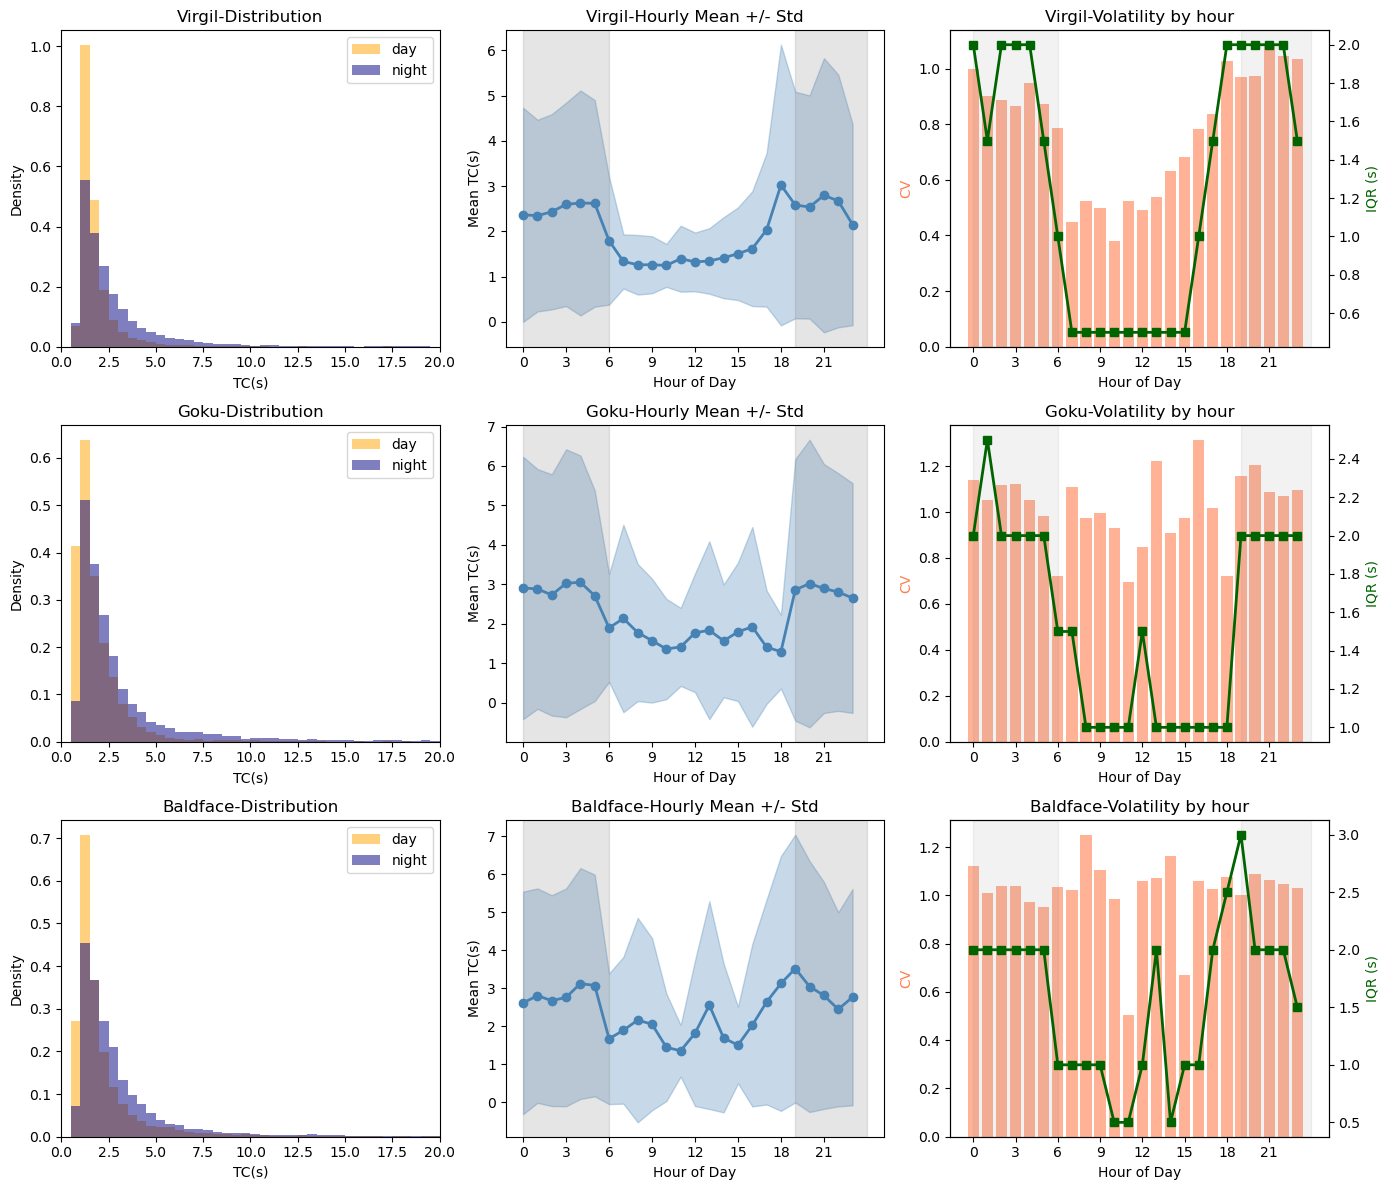

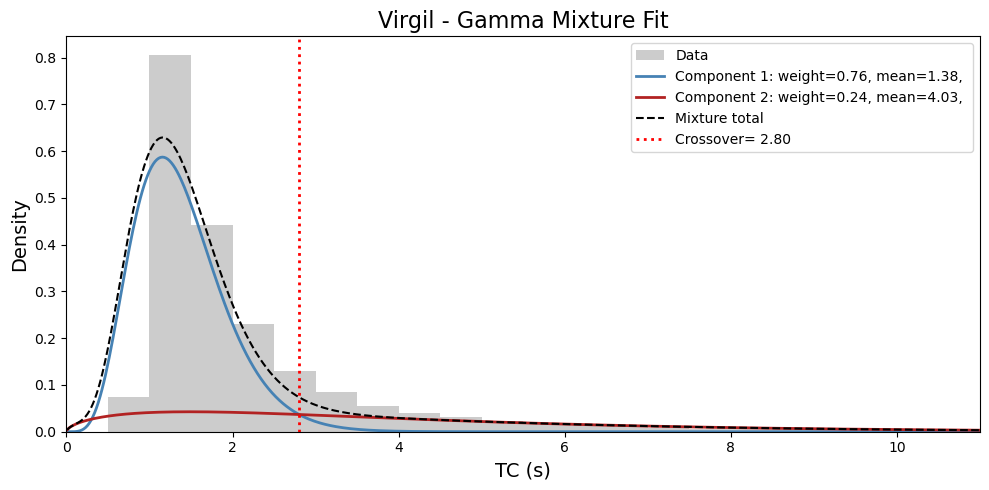

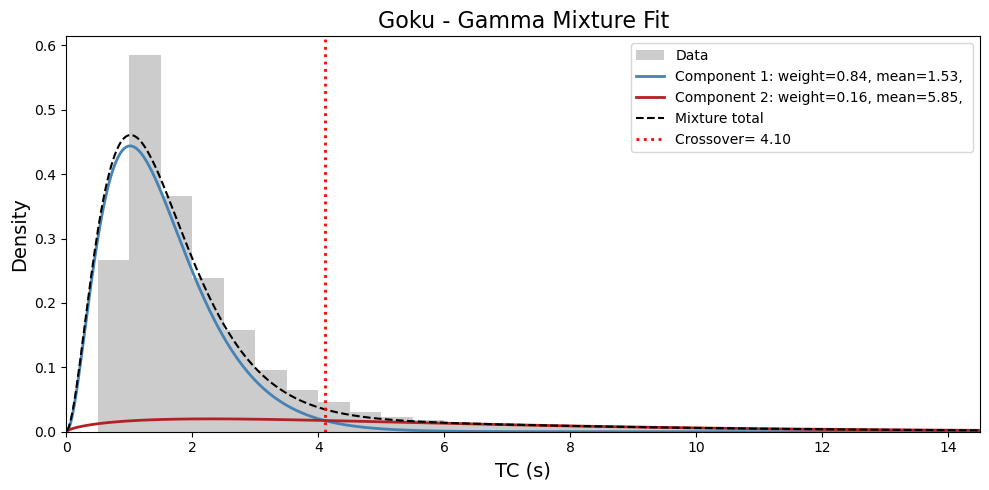

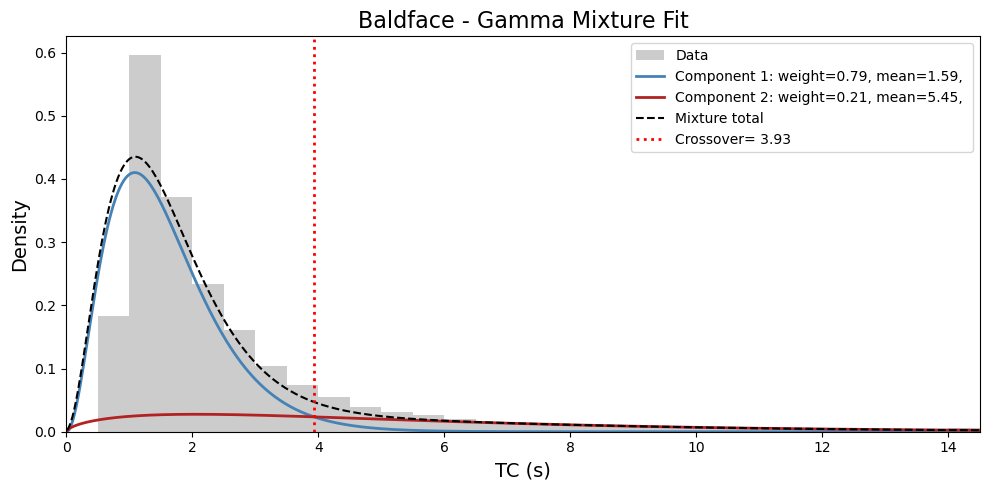

In [10]:
# Full Alpha EDA
fig_alpha,summary_alpha = tc_day_night_distribution(alpha,light_on=6,light_off=19)
print(summary_alpha)
# Hourly volatility table
hourly_alpha = tc_hourly_volatility(alpha,light_on=6,light_off=19)
print(hourly_alpha)
# Mixture fit visualization per subject
for subj in alpha.columns:
    fig, thresh, params = plot_mixture_fit(alpha[subj].values,subj_name=subj)

Check beta

                     n      mean       std  median  iqr        cv   max  \
subject  regime                                                           
Virgil   day     18696  1.639335  1.136452     1.5  1.0  0.693240  25.5   
         night   15828  2.125979  1.635177     1.5  1.5  0.769141  22.0   
Goku     day     18696  1.969325  1.474471     1.5  1.5  0.748719  20.5   
         night   15828  1.876706  1.382977     1.5  1.0  0.736918  24.5   
Baldface day     18696  1.860772  1.301646     1.5  1.0  0.699519  22.0   
         night   15828  2.152104  1.359801     2.0  1.0  0.631847  23.0   

                 mann_whitney_p           ks_p  night_day_ratio  
subject  regime                                                  
Virgil   day      4.612980e-256  2.584107e-263         1.296855  
         night    4.612980e-256  2.584107e-263         1.296855  
Goku     day       1.102758e-07   2.599741e-14         0.952969  
         night     1.102758e-07   2.599741e-14         0.952969  
Bal

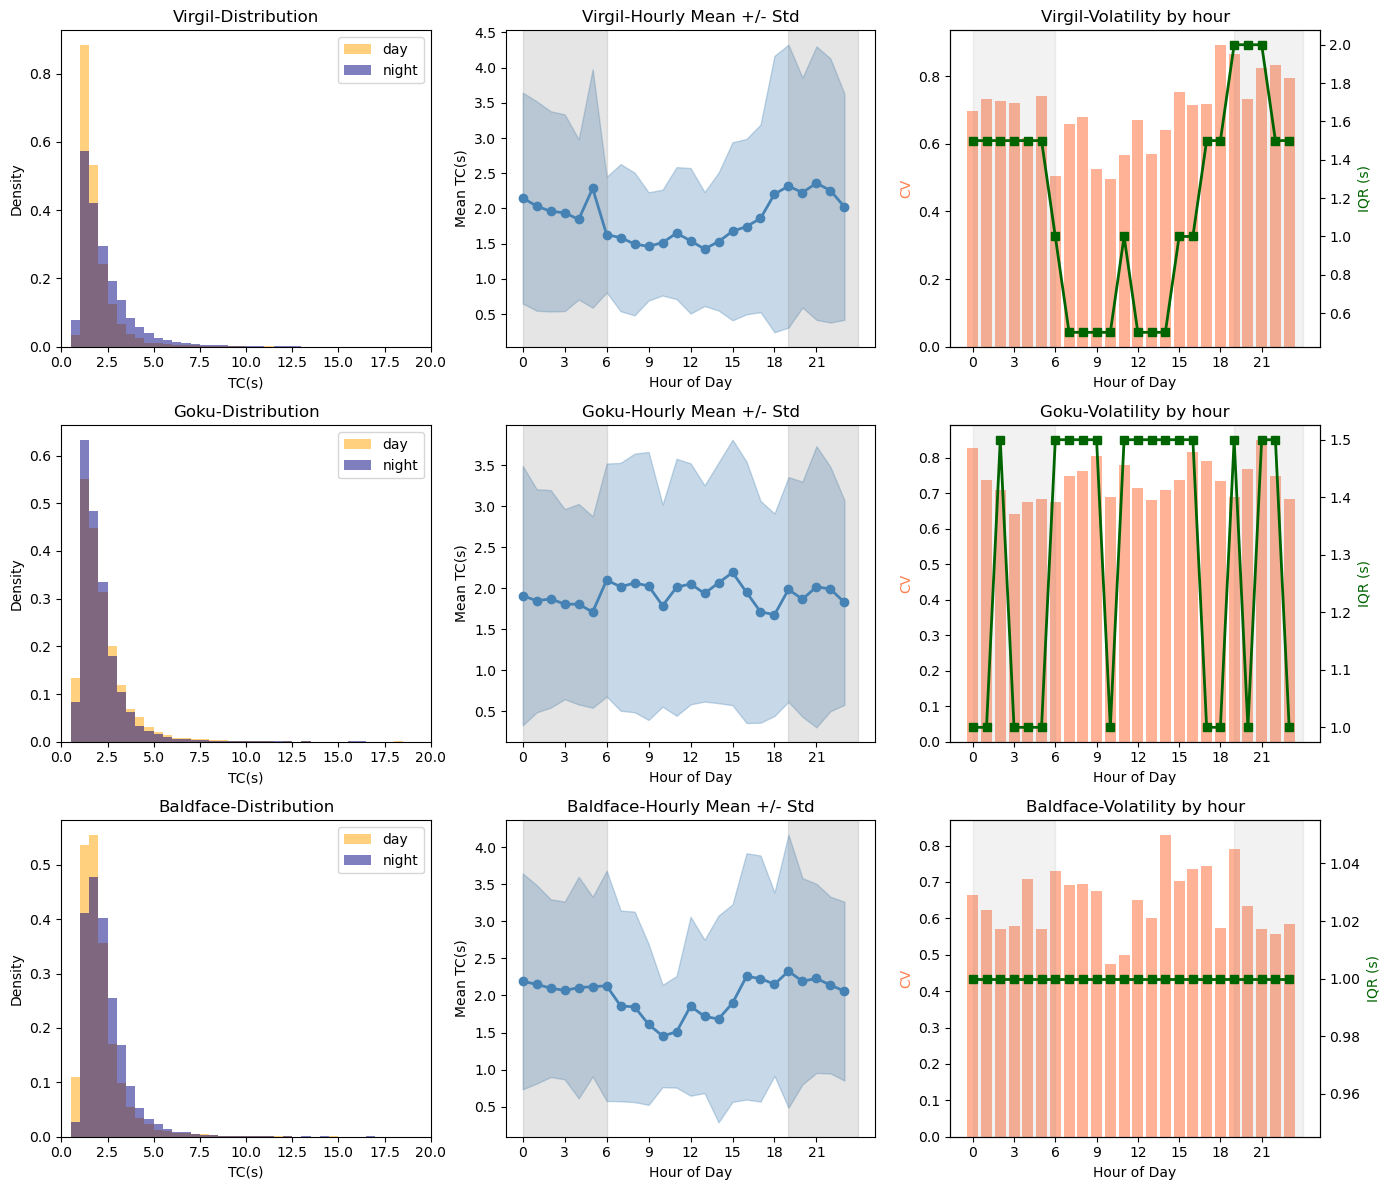

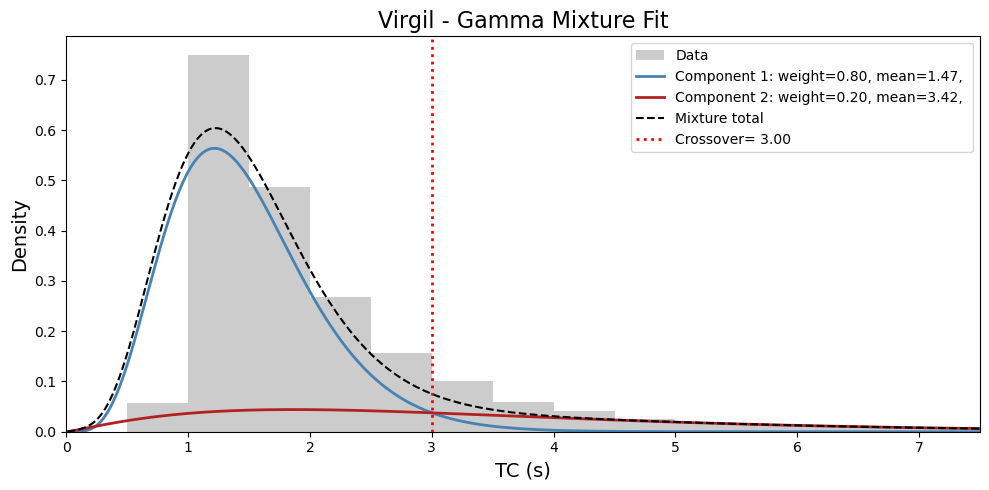

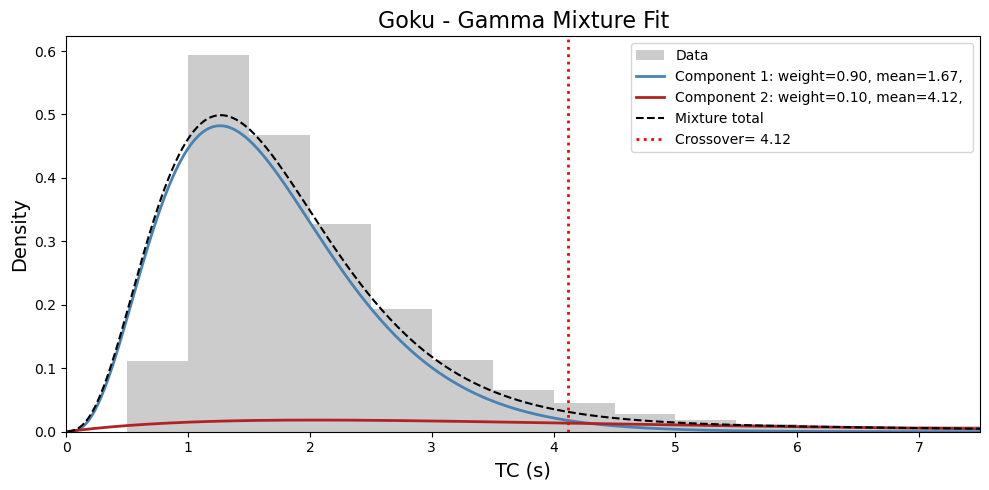

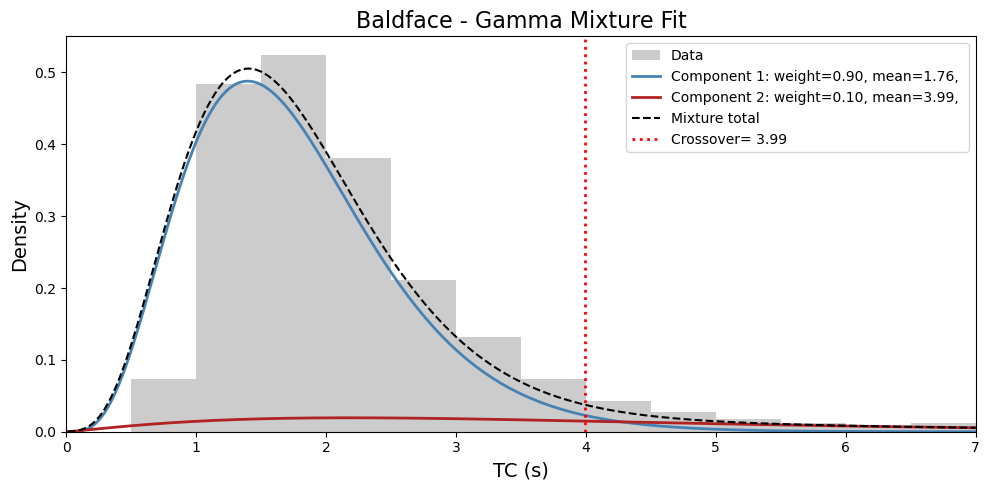

In [11]:
# Full EDA
fig_beta,summary_beta = tc_day_night_distribution(beta,light_on=6,light_off=19)
print(summary_beta)
# Hourly volatility table
hourly_beta = tc_hourly_volatility(beta,light_on=6,light_off=19)
print(hourly_beta)
# Mixture fit visualization per subject
for subj in beta.columns:
    fig, thresh, params = plot_mixture_fit(beta[subj].values,subj_name=subj)

check delta

                     n      mean       std  median  iqr        cv   max  \
subject  regime                                                           
Virgil   day     18696  2.174904  2.093004     1.5  1.5  0.962343  26.5   
         night   15828  2.733036  2.996177     1.5  2.0  1.096281  27.5   
Goku     day     18696  1.830926  1.592785     1.5  1.0  0.869934  24.0   
         night   15828  2.321677  2.257755     1.5  1.5  0.972467  27.0   
Baldface day     18696  2.465046  2.462486     1.5  1.5  0.998961  28.0   
         night   15828  3.688495  3.591710     2.5  3.0  0.973760  27.5   

                 mann_whitney_p           ks_p  night_day_ratio  
subject  regime                                                  
Virgil   day       3.197537e-30   4.641817e-75         1.256624  
         night     3.197537e-30   4.641817e-75         1.256624  
Goku     day      4.857051e-200  2.195009e-202         1.268034  
         night    4.857051e-200  2.195009e-202         1.268034  
Bal

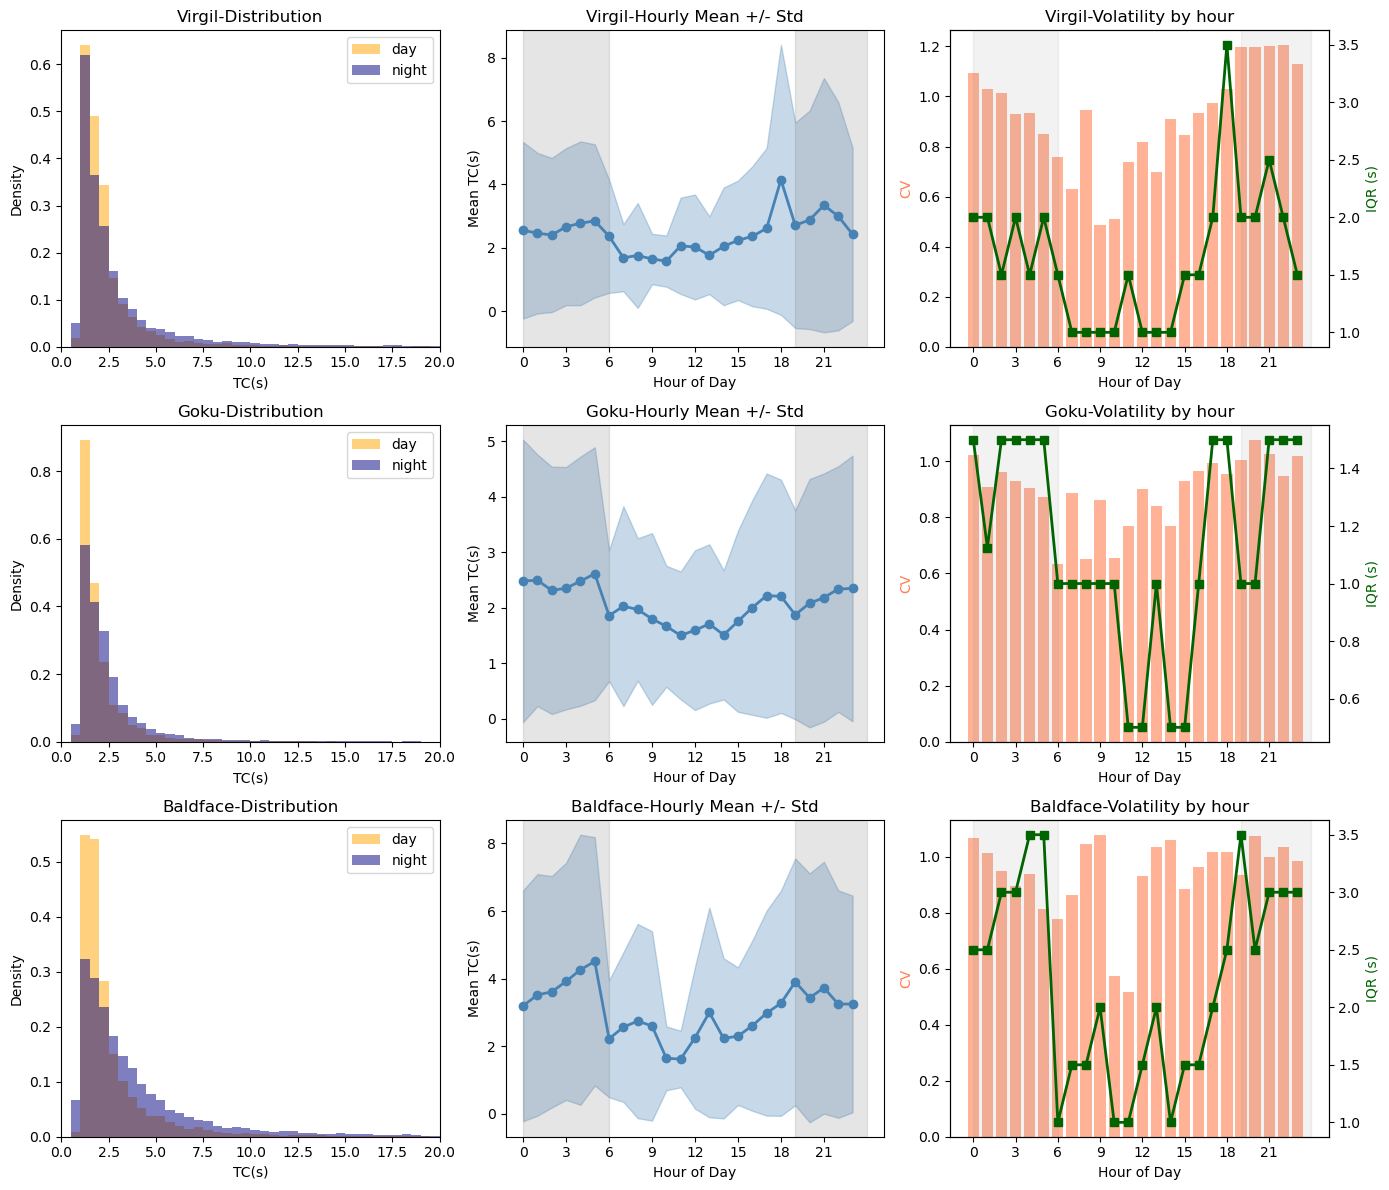

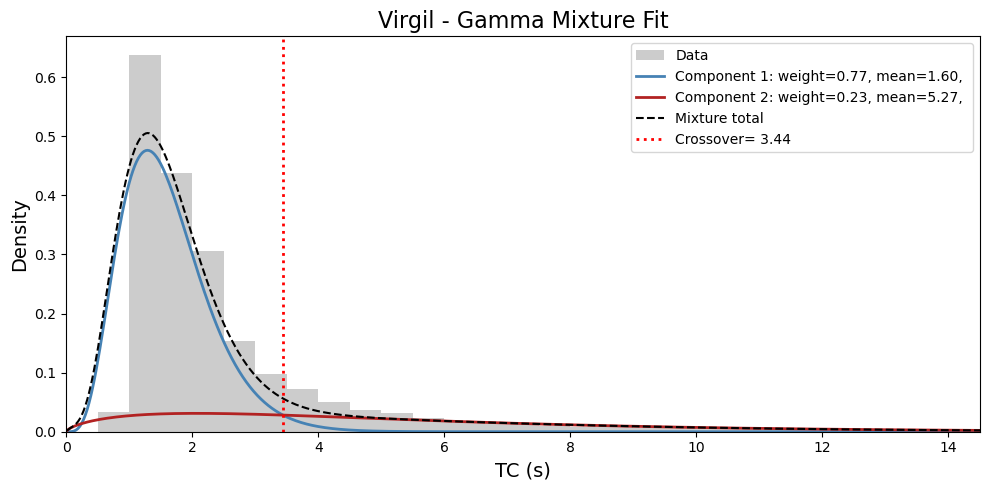

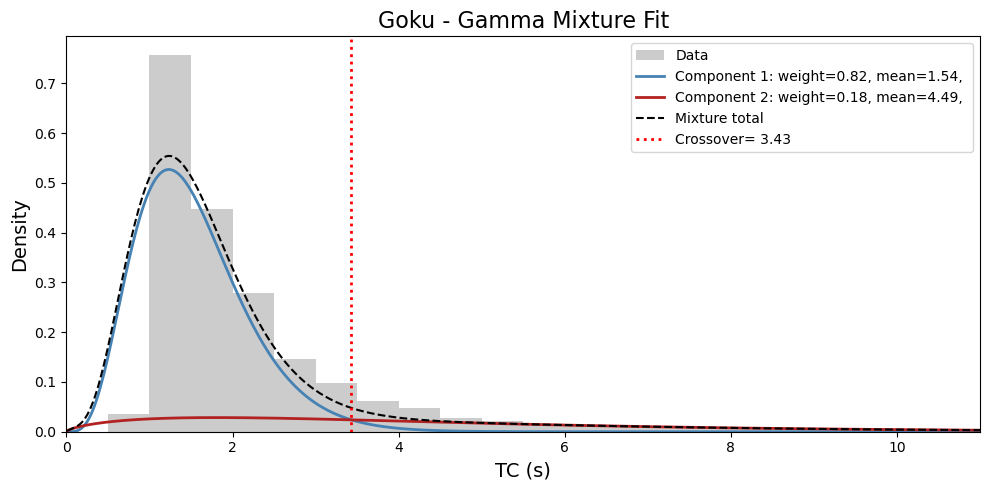

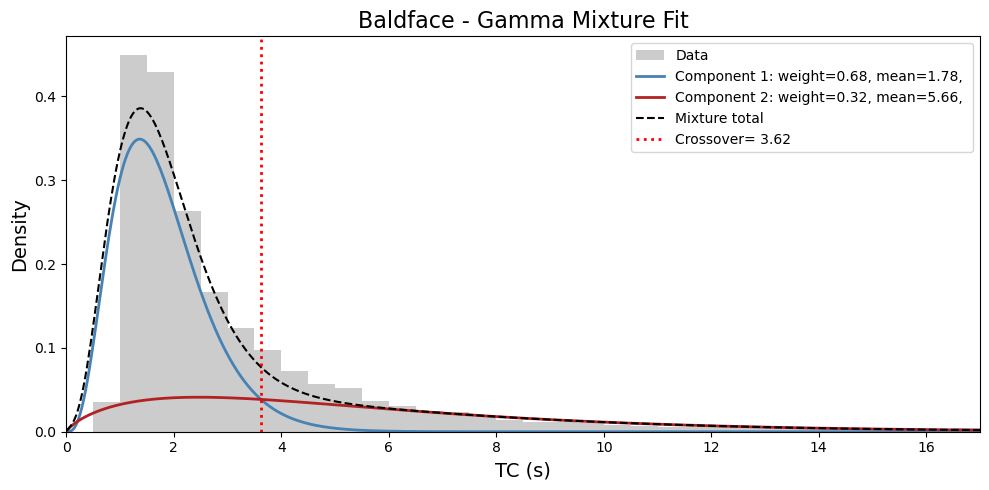

In [12]:
# Full EDA
fig_delta,summary_delta = tc_day_night_distribution(delta,light_on=6,light_off=19)
print(summary_delta)
# Hourly volatility table
hourly_delta = tc_hourly_volatility(delta,light_on=6,light_off=19)
print(hourly_delta)
# Mixture fit visualization per subject
for subj in delta.columns:
    fig, thresh, params = plot_mixture_fit(delta[subj].values,subj_name=subj)

check theta

                     n      mean       std  median  iqr        cv   max  \
subject  regime                                                           
Virgil   day     18696  1.589083  1.390775     1.0  0.5  0.875206  26.5   
         night   15828  2.695034  2.827097     2.0  2.0  1.049002  28.0   
Goku     day     18696  1.799529  1.979260     1.0  1.0  1.099877  24.5   
         night   15828  3.210861  3.709315     2.0  2.5  1.155240  29.5   
Baldface day     18696  2.232697  2.525700     1.5  1.5  1.131233  27.5   
         night   15828  4.211366  4.075573     3.0  3.5  0.967756  29.5   

                 mann_whitney_p  ks_p  night_day_ratio  
subject  regime                                         
Virgil   day                0.0   0.0         1.695968  
         night              0.0   0.0         1.695968  
Goku     day                0.0   0.0         1.784278  
         night              0.0   0.0         1.784278  
Baldface day                0.0   0.0         1.886224  


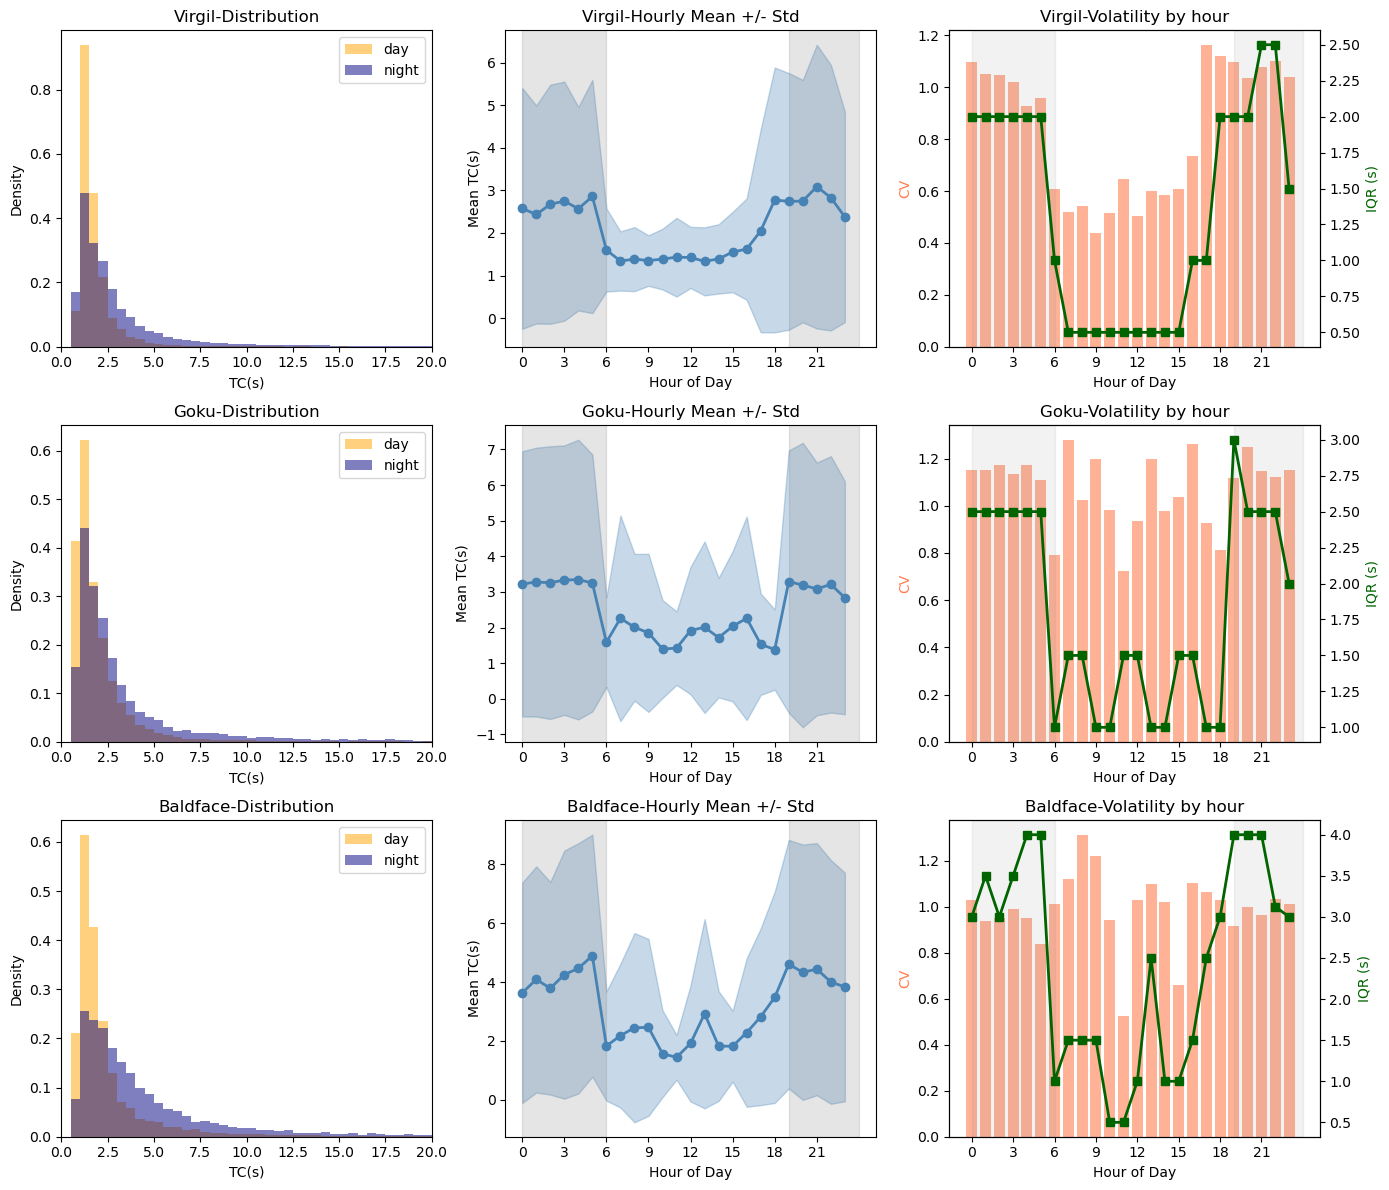

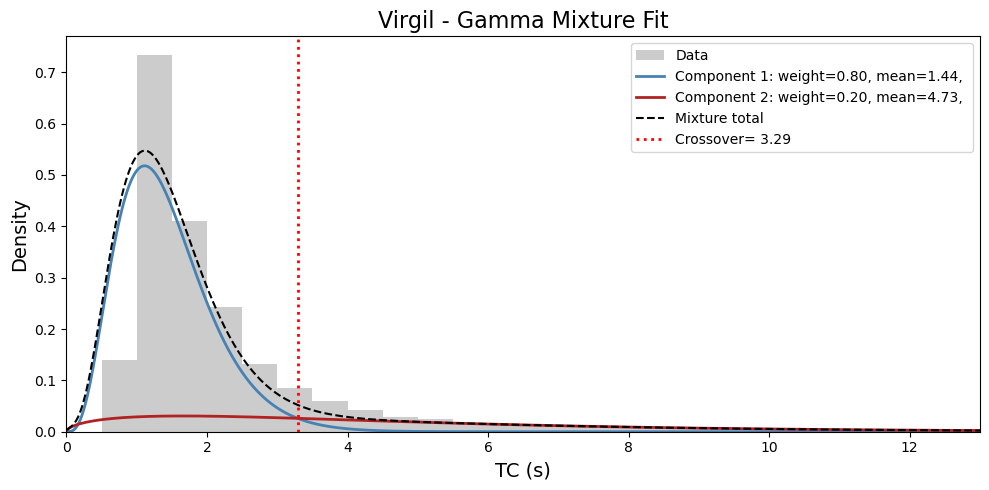

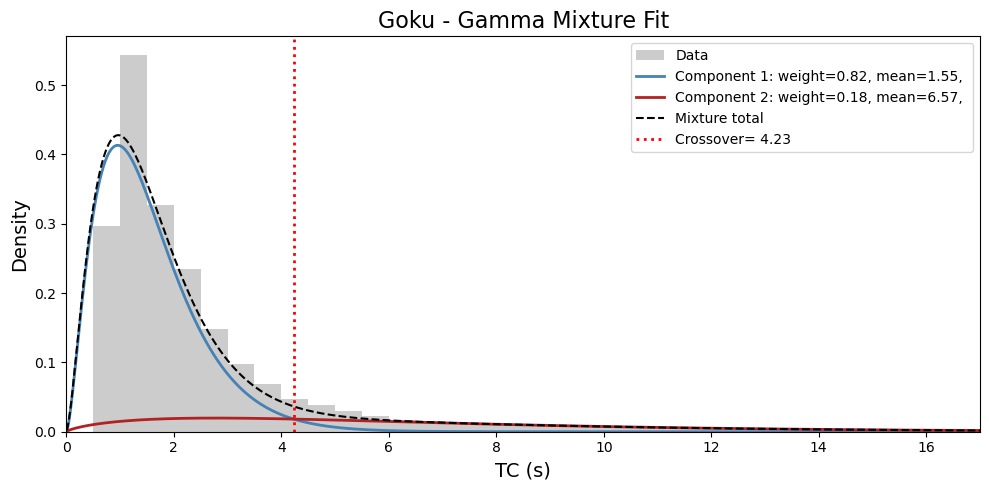

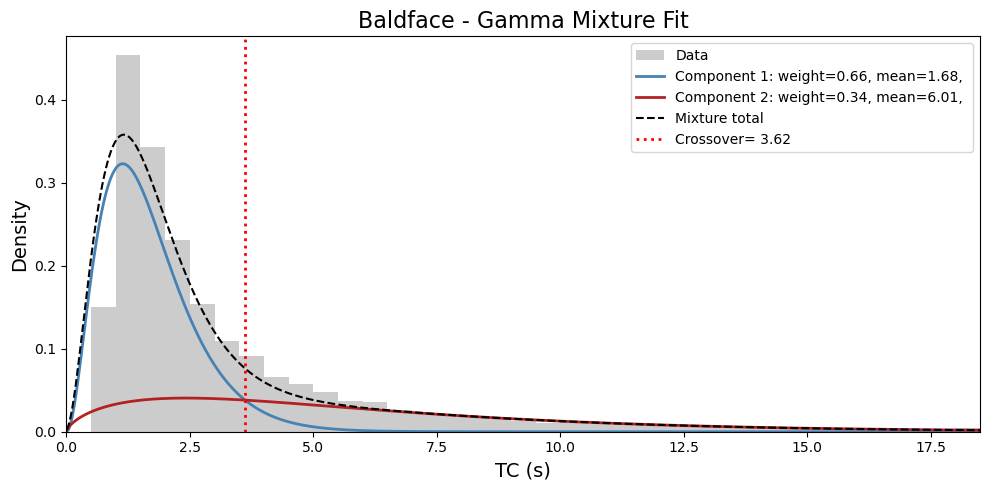

In [13]:
 # Full EDA
fig_theta,summary_theta = tc_day_night_distribution(theta,light_on=6,light_off=19)
print(summary_theta)
# Hourly volatility table
hourly_theta = tc_hourly_volatility(theta,light_on=6,light_off=19)
print(hourly_theta)
# Mixture fit visualization per subject
for subj in theta.columns:
    fig, thresh, params = plot_mixture_fit(theta[subj].values,subj_name=subj)

In [14]:
hourly_beta

is_light     n      mean       std  median  iqr        cv  \
subject  hour                                                              
Virgil   0        False  1440  2.147222  1.496995     1.5  1.5  0.697177   
         1        False  1440  2.034375  1.486574     1.5  1.5  0.730728   
         2        False  1440  1.958681  1.420903     1.5  1.5  0.725439   
         3        False  1440  1.938889  1.396442     1.5  1.5  0.720228   
         4        False  1440  1.844097  1.137292     1.5  1.5  0.616720   
...                 ...   ...       ...       ...     ...  ...       ...   
Baldface 19       False  1440  2.326736  1.839838     2.0  1.0  0.790738   
         20       False  1440  2.190625  1.390283     2.0  1.0  0.634651   
         21       False  1440  2.229514  1.275033     2.0  1.0  0.571888   
         22       False  1440  2.139236  1.191186     2.0  1.0  0.556828   
         23       False  1440  2.058333  1.205472     2.0  1.0  0.585654   

                   skew   kurtosis   max  
subject  hour                             
Virgil   0     2.466428   9.545738  12.0  
         1     2.794250  13.227249  15.0  
         2     3.297435  18.644883  16.0  
         3     3.923708  30.525397  19.5  
         4     2.535477  10.476068  10.0  
...                 ...        ...   ...  
Baldface 19    4.700632  32.885448  21.5  
         20    3.299485  21.444966  17.0  
         21    2.369920  10.695244  14.5  
         22    1.770752   4.659899  10.0  
         23    3.024030  20.516739  16.0  

[72 rows x 10 columns]

Plot the hourly shape information

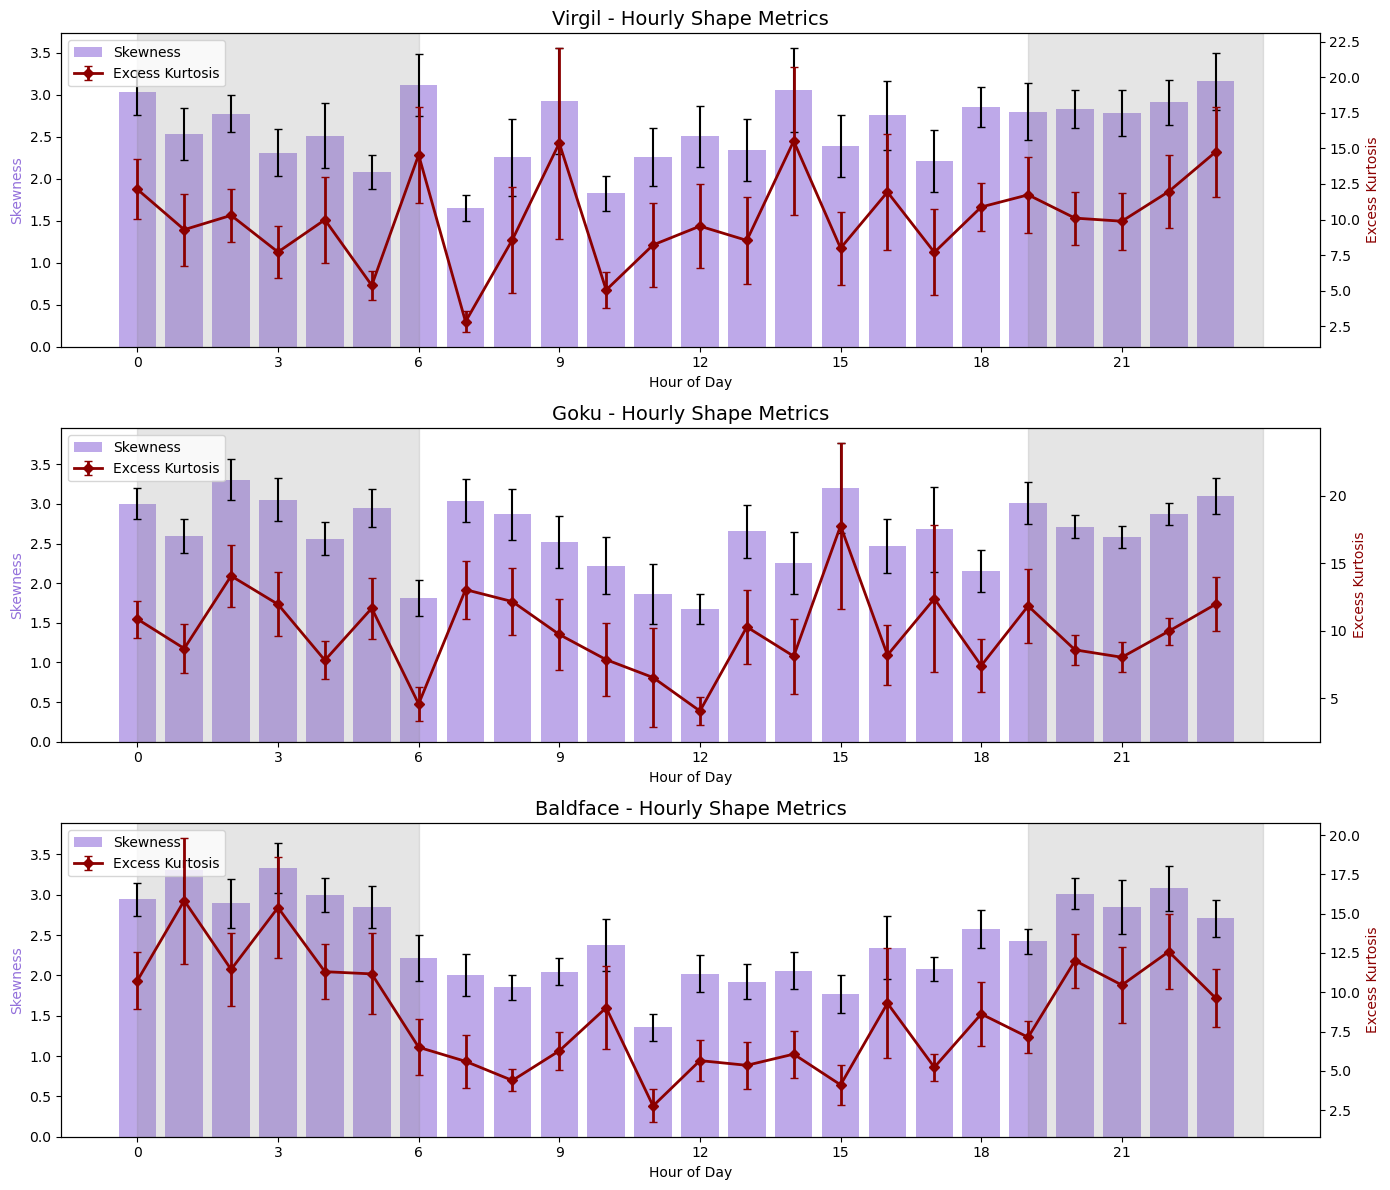

In [15]:
def plot_hourly_shape(df,light_on=6,light_off=19,figsize=(14,4)):
    """
    Plot hourly skewness (bars) and excess kurtosis (line) for each subject

    Parameters:
    df: pd.DataFrame (index: datetime, columns: subjects with TC values)
    light_on, light_off: inf; Light cycle boundaries
    figsize: tuple; Figure size

    Returns:
    fig: matplotlib.figure.Figure
    shape_df: pd.DataFrame with hourly skewness and kurtosis for each subject
    """
    min_n=10
    subjects = df.columns.tolist()
    n_subj=len(subjects)
    fig,axes = plt.subplots(n_subj,1,figsize=(figsize[0],figsize[1]*n_subj),squeeze=False)
    records = []
    for i, subj in enumerate(subjects):
        vals = df[subj].dropna()
        day_hour = vals.groupby([vals.index.date,vals.index.hour])
        dh_skew = day_hour.skew()
        dh_kurt=day_hour.apply(pd.Series.kurtosis)
        dh_n = day_hour.count()
        dh = pd.DataFrame({
            'skewness':dh_skew.values,
            'kurtosis':dh_kurt.values,
            'n':dh_n.values
        },index=pd.MultiIndex.from_tuples(dh_skew.index,names=['date','hour']))
        # drop bins with too few samples for meaningful shape estimates
        dh = dh[dh['n']>=min_n]
        # average across days for each hour-of-day
        by_hour = dh.groupby('hour')
        h_skew_mean = by_hour['skewness'].mean()
        h_skew_sem = by_hour['skewness'].sem()
        h_kurt_mean = by_hour['kurtosis'].mean()
        h_kurt_sem = by_hour['kurtosis'].sem()
        h_n_mean = by_hour['n'].mean()
        h_n_days = by_hour['n'].count()
        for h in h_skew_mean.index:
            records.append({
                'subject':subj,'hour':h,
                'skewness_mean':h_skew_mean[h],'skewness_sem':h_skew_sem[h],
                'kurtosis_mean':h_kurt_mean[h],'kurtosis_sem':h_kurt_sem[h],
                'n_per_bin_mean':h_n_mean[h],'n_days':h_n_days[h]
            })
        # Plot
        ax = axes[i,0]
        ax2 = ax.twinx()
        ax.bar(h_skew_mean.index,h_skew_mean,yerr = h_skew_sem,
                color = 'mediumpurple',alpha=0.6,capsize = 3, label='Skewness')
        ax2.errorbar(h_kurt_mean.index,h_kurt_mean,yerr=h_kurt_sem,fmt='D-',
                     color='darkred',linewidth=2,markersize=5,capsize=3,label='Excess Kurtosis')
        ax.axvspan(0,light_on,color='gray',alpha=0.2)
        ax.axvspan(light_off,24,color='gray',alpha=0.2)
        ax.set_xlabel('Hour of Day')
        ax.set_ylabel('Skewness',color='mediumpurple')
        ax2.set_ylabel('Excess Kurtosis',color='darkred')
        ax.set_title(f'{subj} - Hourly Shape Metrics',fontsize=14)
        ax.set_xticks(range(0,24,3))
        h1,l1=ax.get_legend_handles_labels()
        h2,l2=ax2.get_legend_handles_labels()
        ax.legend(h1+h2,l1+l2,loc='upper left',fontsize=10)
    plt.tight_layout()
    shape_df = pd.DataFrame(records).set_index(['subject','hour'])
    return fig, shape_df

fig,shape_df = plot_hourly_shape(alpha,light_on=6,light_off=19)

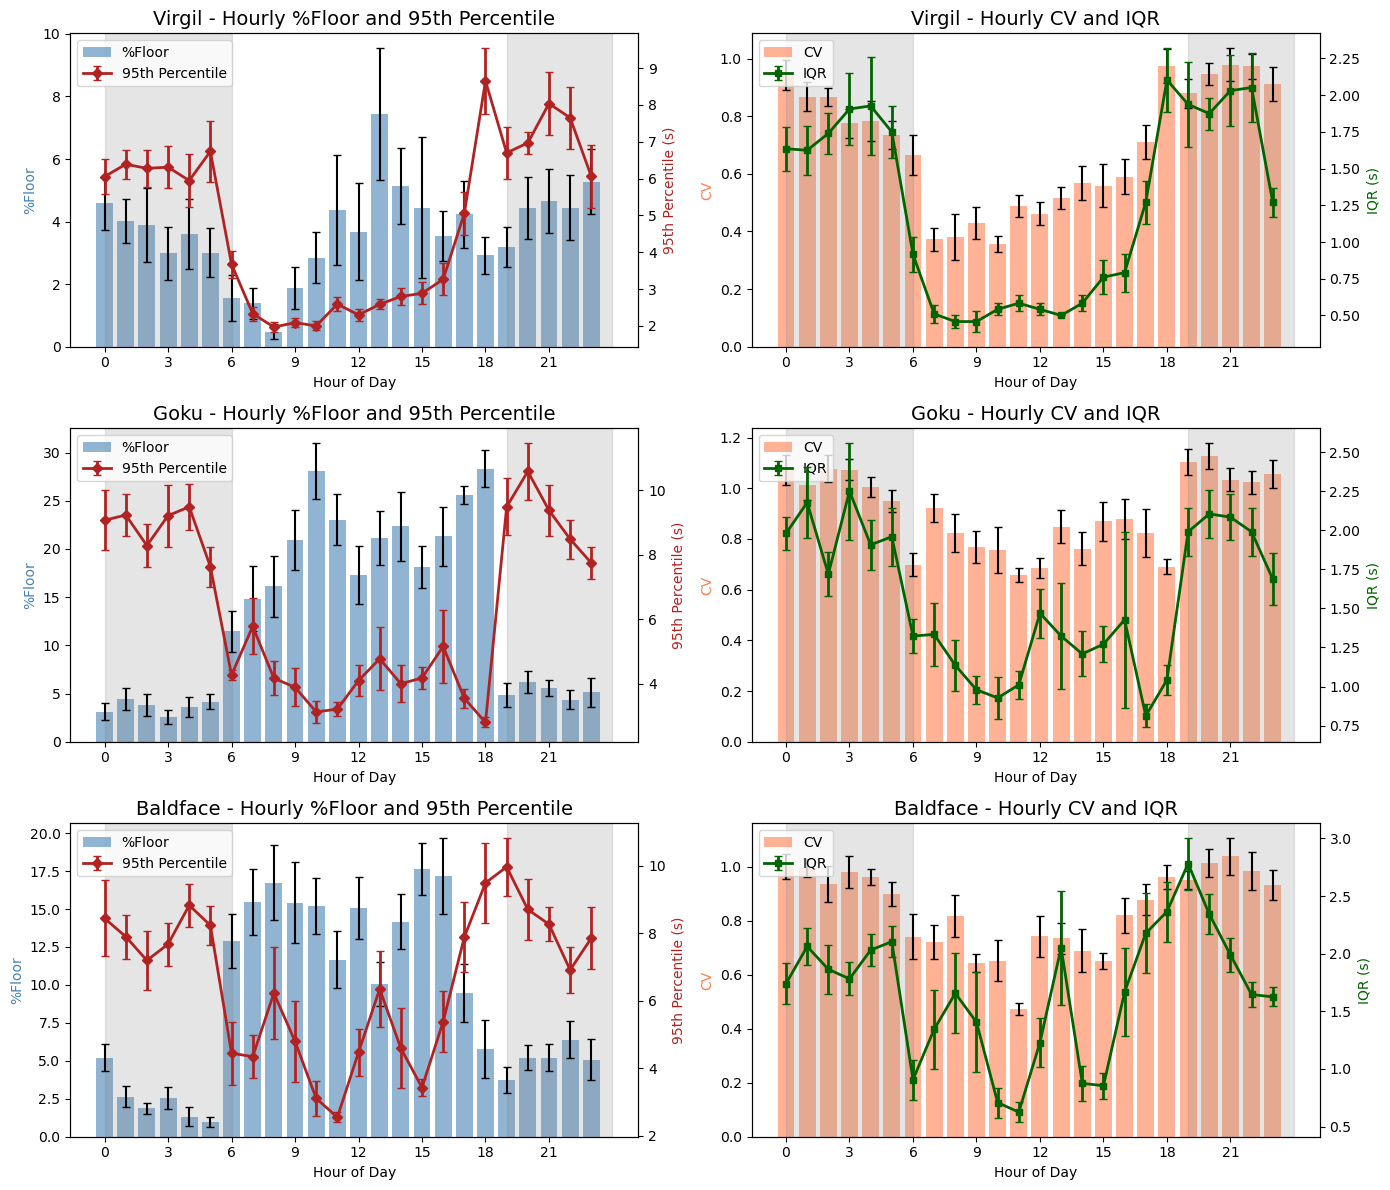

In [17]:
def plot_hourly_descriptives(df,light_on=6,light_off=19,tc_floor=0.5,min_n=10,figsize=(14,4)):
    """
    Plot hourly %Floor (bars) and CV (line) for each subject
    computed per-day then averaged (mean +/- SEM)

    Parameters:
    df: pd.DataFrame (index: DatetimeIndex, columns: subjects with TC values)
    light_on, light_off: int; light cycle boundaries
    tc_floor: float; measurement floor for TC
    min_n: int; minimum samples per day-hour bin
    figsize:tuple

    Returns:
    fig: matplotlib.figure.Figure
    desc_df: pd.DataFrame with hourly descriptives for each subject
    """
    subjects=df.columns.tolist()
    n_subj=len(subjects)
    fig,axes = plt.subplots(n_subj,2,figsize=(figsize[0],figsize[1]*n_subj),squeeze=False)
    records = []
    for i, subj in enumerate(subjects):
        vals = df[subj].dropna()
        day_hour = vals.groupby([vals.index.date,vals.index.hour])
        # Per day-hour bin metrics
        dh_mean = day_hour.mean()
        dh_std = day_hour.std()
        dh_cv = day_hour.apply(lambda x:x.std()/x.mean() if x.mean()>0 else np.nan)
        dh_iqr = day_hour.apply(lambda x:x.quantile(0.75)-x.quantile(0.25))
        dh_p95 = day_hour.apply(lambda x:np.percentile(x,95))
        dh_floor = day_hour.apply(lambda x:(x<=tc_floor).mean()*100)
        dh_n = day_hour.count()

        dh=pd.DataFrame({
            'mean':dh_mean.values,
            'std':dh_std.values,
            'cv':dh_cv.values,
            'iqr':dh_iqr.values,
            'p95':dh_p95.values,
            'pct_floor':dh_floor.values,
            'n':dh_n.values
        },index=pd.MultiIndex.from_tuples(dh_mean.index,names=['date','hour']))
        dh = dh[dh['n']>=min_n]
        # Average across days for each hour-of-day
        by_hour = dh.groupby('hour')
        metrics = ['mean','cv','iqr','p95','pct_floor']
        h_stats = {}
        for m in metrics:
            h_stats[f'{m}_mean'] = by_hour[m].mean()
            h_stats[f'{m}_sem'] = by_hour[m].sem()
        h_stats['n_days']=by_hour['n'].count()
        h_stats['n_per_bin_mean']=by_hour['n'].mean() 
        for h in h_stats['mean_mean'].index:
            rec = {'subject':subj,'hour':h}
            for m in metrics:
                rec[f'{m}_mean']=h_stats[f'{m}_mean'][h]
                rec[f'{m}_sem']=h_stats[f'{m}_sem'][h]
            rec['n_days']=h_stats['n_days'][h]
            rec['n_per_bin_mean']=h_stats['n_per_bin_mean'][h]
            records.append(rec)
        # Left panel: %Floor (bars)+p95 (line)
        ax = axes[i,0]
        ax2 = ax.twinx()
        hours = h_stats['pct_floor_mean'].index
        ax.bar(hours,h_stats['pct_floor_mean'],yerr=h_stats['pct_floor_sem'],
               color='steelblue',alpha=0.6,capsize=3,label='%Floor')
        ax2.errorbar(hours,h_stats['p95_mean'],yerr=h_stats['p95_sem'],fmt='D-',color='firebrick',
                     linewidth=2,markersize=5,capsize=3,label='95th Percentile')
        ax.axvspan(0,light_on,color='gray',alpha=0.2)
        ax.axvspan(light_off,24,color='gray',alpha=0.2)
        ax.set_xlabel('Hour of Day')
        ax.set_ylabel('%Floor',color='steelblue')
        ax2.set_ylabel('95th Percentile (s)',color='firebrick')
        ax.set_title(f'{subj} - Hourly %Floor and 95th Percentile',fontsize=14)
        ax.set_xticks(range(0,24,3))
        h1,l1=ax.get_legend_handles_labels()
        h2,l2=ax2.get_legend_handles_labels()
        ax.legend(h1+h2,l1+l2,loc='upper left',fontsize=10)
        # Right panel: CV (line) + IQR (line)
        ax = axes[i,1]
        ax2 = ax.twinx()
        ax.bar(hours,h_stats['cv_mean'],yerr=h_stats['cv_sem'],
               color='coral',alpha=0.6,capsize=3,label='CV')
        ax2.errorbar(hours,h_stats['iqr_mean'],yerr=h_stats['iqr_sem'],fmt='s-',color='darkgreen',
                     linewidth=2,markersize=5,capsize=3,label='IQR')
        ax.axvspan(0,light_on,color='gray',alpha=0.2)
        ax.axvspan(light_off,24,color='gray',alpha=0.2)
        ax.set_xlabel('Hour of Day')
        ax.set_ylabel('CV',color='coral')
        ax2.set_ylabel('IQR (s)',color='darkgreen')
        ax.set_title(f'{subj} - Hourly CV and IQR',fontsize=14)
        ax.set_xticks(range(0,24,3))
        h1,l1=ax.get_legend_handles_labels()
        h2,l2=ax2.get_legend_handles_labels()
        ax.legend(h1+h2,l1+l2,loc='upper left',fontsize=10)
    plt.tight_layout()
    desc_df = pd.DataFrame(records).set_index(['subject','hour'])
    return fig, desc_df

fig, desc_df = plot_hourly_descriptives(alpha,light_on=6,light_off=19)



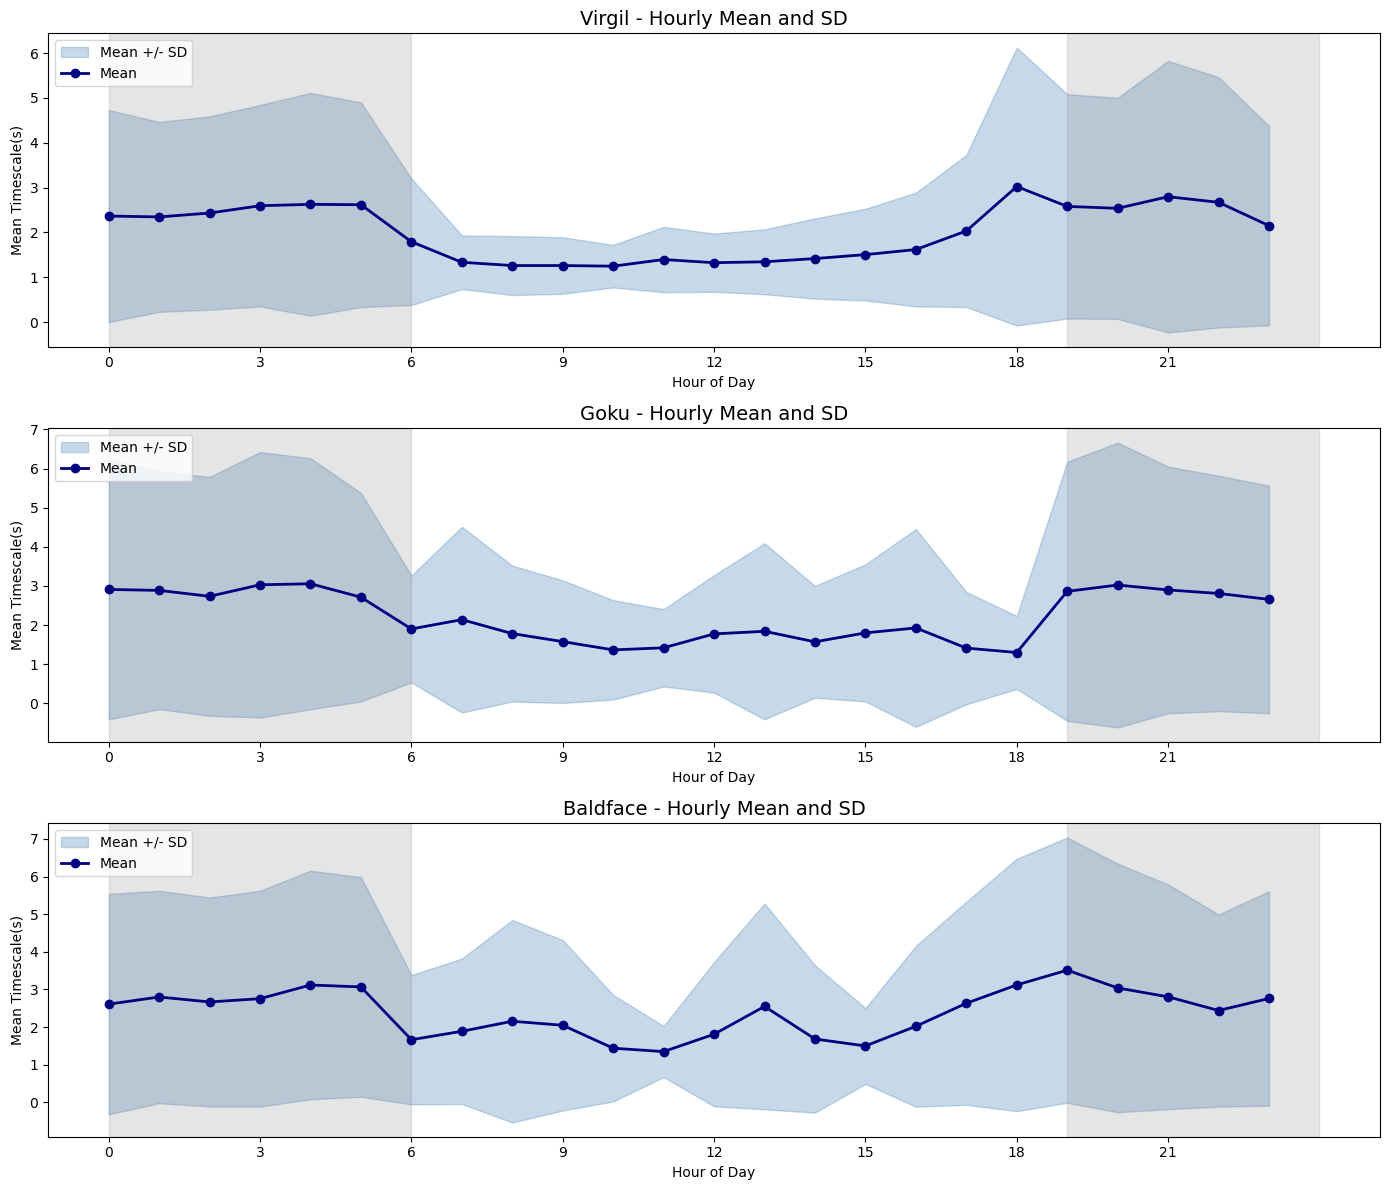

In [ ]:
def plot_hourly_mean_iqr(df,light_on=6,light_off=19,figsize=(14,4)):
    """basically the function name tells the story"""
    min_n =10
    subjects = df.columns.tolist()
    n_subj=len(subjects)
    fig,axes = plt.subplots(
        n_subj,1,
        figsize=(figsize[0],figsize[1]*n_subj),
        squeeze=False
    )
    records = []
    for i, subj in enumerate(subjects):
        vals = df[subj].dropna()
        by_hour = vals.groupby(vals.index.hour)
        h_mean = by_hour.mean()
        h_sd = by_hour.std()
        h_sem = by_hour.sem()
        h_n=by_hour.count()
        summary = pd.DataFrame({
            'mean':h_mean,
            'sd':h_sd,
            'sem':h_sem,
            'lower_sd':h_mean-h_sd,
            'upper_sd':h_mean+h_sd,
            'n':h_n
        })
        summary = summary[summary['n']>=min_n]
        for h in summary.index:
            records.append({
                'subject':subj,
                'hour':h,
                'mean':summary.loc[h,'mean'],
                'sd':summary.loc[h,'sd'],
                'sem':summary.loc[h,'sem'],
                'lower_sd':summary.loc[h,'lower_sd'],
                'upper_sd':summary.loc[h,'upper_sd'],
                'n':summary.loc[h,'n']
            })
        ax = axes[i,0]
        x = summary.index.to_numpy(dtype=float)
        y = summary['mean'].to_numpy(dtype=float)
        lower = summary['lower_sd'].to_numpy(dtype=float)
        upper = summary['upper_sd'].to_numpy(dtype=float)
        ax.fill_between(x,lower,upper,alpha=0.3,color='steelblue',label='Mean +/- SD')
        ax.plot(x,y,'o-',linewidth=2,color='navy',label='Mean')
        ax.axvspan(0,light_on,color='gray',alpha=0.2)
        ax.axvspan(light_off,24,color='gray',alpha=0.2)
        ax.set_xlabel('Hour of Day')
        ax.set_ylabel('Mean Timescale(s)')
        ax.set_title(f'{subj} - Hourly Mean and SD',fontsize=14)
        ax.set_xticks(range(0,24,3))
        ax.legend(loc='upper left',fontsize=10)
    plt.tight_layout()
    summary_df = pd.DataFrame(records).set_index(['subject','hour'])
    return fig, summary_df

fig, summary_df = plot_hourly_mean_iqr(alpha,light_on=6,light_off=19)

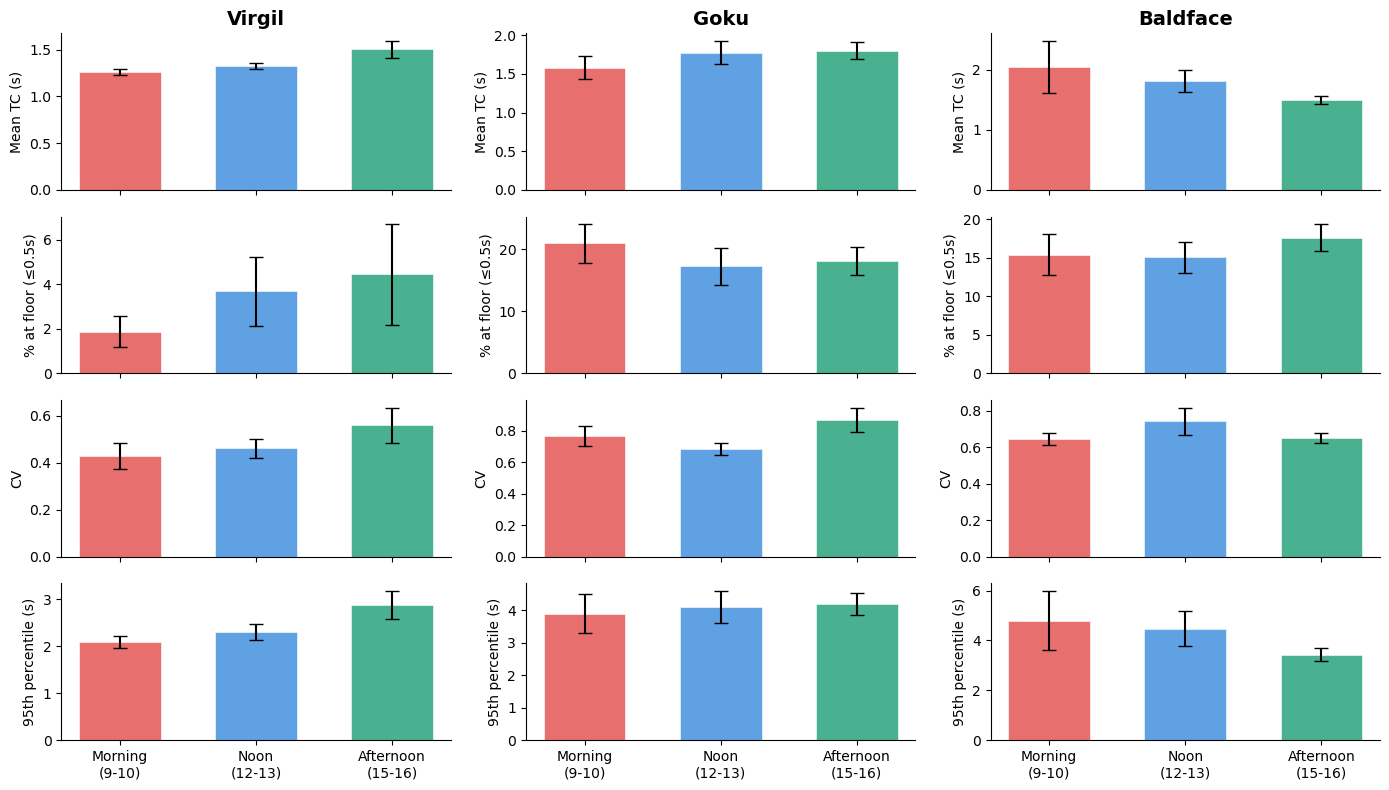

In [18]:
def plot_pvt_window_tc(df, tc_floor=0.5, min_n=10, figsize=(14, 8)):
    """
    Bar plots of TC metrics at the 3 PVT session windows.
    Per-day then averaged (mean ± SEM).
    """
    subjects = df.columns.tolist()
    windows = {'Morning\n(9-10)': 9, 'Noon\n(12-13)': 12, 'Afternoon\n(15-16)': 15}
    metrics = ['mean', 'pct_floor', 'cv', 'p95']
    labels = {'mean': 'Mean TC (s)', 'pct_floor': f'% at floor (≤{tc_floor}s)',
              'cv': 'CV', 'p95': '95th percentile (s)'}
    colors = {'Morning\n(9-10)': '#E24B4A', 'Noon\n(12-13)': '#378ADD',
              'Afternoon\n(15-16)': '#1D9E75'}

    df = df.copy()
    df.index = pd.to_datetime(df.index)

    # Compute per-day metrics at each window
    data = {}
    for subj in subjects:
        data[subj] = {}
        vals = df[subj].dropna()
        for wname, hr in windows.items():
            day_groups = vals[vals.index.hour == hr].groupby(vals[vals.index.hour == hr].index.date)
            day_vals = []
            for date, grp in day_groups:
                x = grp.values
                if len(x) < min_n:
                    continue
                day_vals.append({
                    'mean': np.mean(x),
                    'pct_floor': (x <= tc_floor).mean() * 100,
                    'cv': np.std(x, ddof=1) / np.mean(x) if np.mean(x) > 0 else np.nan,
                    'p95': np.percentile(x, 95),
                })
            dm = pd.DataFrame(day_vals)
            data[subj][wname] = {
                m: (dm[m].mean(), dm[m].sem()) for m in metrics
            }

    n_subj = len(subjects)
    fig, axes = plt.subplots(len(metrics), n_subj, figsize=figsize, squeeze=False)

    x_pos = np.arange(len(windows))
    width = 0.6
    wnames = list(windows.keys())

    for col, subj in enumerate(subjects):
        for row, m in enumerate(metrics):
            ax = axes[row, col]
            means = [data[subj][w][m][0] for w in wnames]
            sems = [data[subj][w][m][1] for w in wnames]
            bars = ax.bar(x_pos, means, width, yerr=sems, capsize=5,
                          color=[colors[w] for w in wnames], alpha=0.8,
                          edgecolor='white', linewidth=0.5)
            ax.set_xticks(x_pos)
            ax.set_xticklabels(wnames if row == len(metrics) - 1 else [''] * 3)
            ax.set_ylabel(labels[m])
            if row == 0:
                ax.set_title(subj, fontsize=14, fontweight='bold')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

    plt.tight_layout()
    return fig
fig = plot_pvt_window_tc(alpha, tc_floor=0.5)

Evaluate the daily consistency

 subject    metric  n_days  friedman_stat  friedman_p  page_L    page_z   page_p  pct_morn_vs_aftn  pct_monotonic  kendall_W
  Virgil      mean      12       3.500000    0.173774   153.0  1.837117 0.033096         75.000000      50.000000   0.145833
  Virgil pct_floor      12       0.820513    0.663480   142.0 -0.408248 0.658454         33.333333       0.000000   0.027778
  Virgil        cv      12       1.166667    0.558035   149.0  1.020621 0.153717         66.666667      33.333333   0.048611
  Virgil       p95      12       2.930233    0.231051   151.5  1.530931 0.062893         66.666667      16.666667   0.109375
    Goku      mean      12       4.166667    0.124514   154.0  2.041241 0.020613         75.000000      41.666667   0.173611
    Goku pct_floor      12       1.217391    0.544060   145.0  0.204124 0.419128         50.000000      25.000000   0.048611
    Goku        cv      12       2.666667    0.263597   148.0  0.816497 0.207108         58.333333      16.666667   0.111111


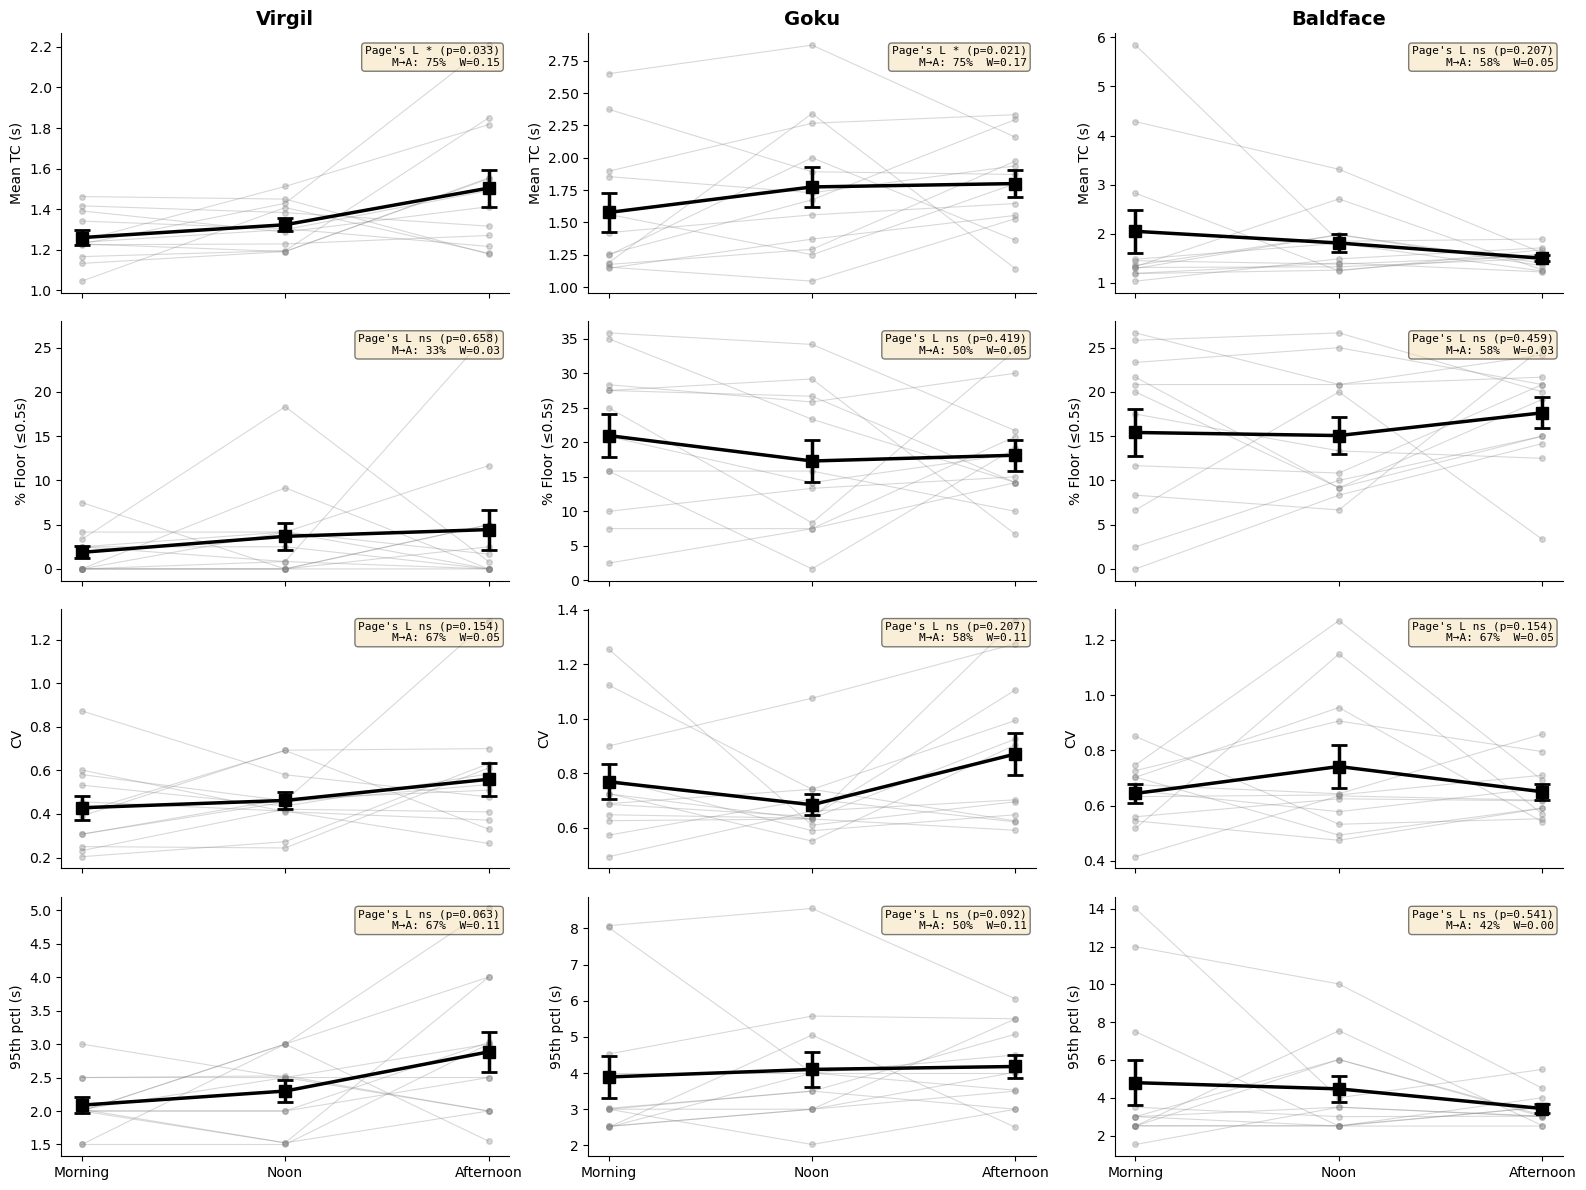

In [25]:
def pvt_window_consistency(df, tc_floor=0.5, min_n=10, figsize=(16, 12)):
    """
    Assess day-to-day consistency of TC metrics at the 3 PVT windows.
    
    For each day and metric:
    - Spaghetti plot (each day as a line across 3 sessions)
    - Friedman test (nonparametric repeated measures)
    - Page's L test (ordered alternative: Morning < Noon < Afternoon)
    - Ordering consistency (% of days where Morning < Afternoon)
    - Kendall's W (concordance across days)
    """
    from scipy.stats import friedmanchisquare, rankdata, norm
    
    def pages_L(mat, reverse=False):
        """
        Page's L test for ordered alternatives.
        H1: column 0 < column 1 < column 2 (or reversed).
        Returns L, z, p (one-tailed).
        """
        if reverse:
            mat = mat[:, ::-1]
        n, k = mat.shape
        ranks = np.zeros_like(mat, dtype=float)
        for i in range(n):
            ranks[i] = rankdata(mat[i])
        rank_sums = ranks.sum(axis=0)
        predicted = np.arange(1, k + 1)
        L = np.sum(predicted * rank_sums)
        E_L = n * k * (k + 1)**2 / 4
        Var_L = n * k**2 * (k + 1) * (k**2 - 1) / 144
        z = (L - E_L) / np.sqrt(Var_L)
        p = 1 - norm.cdf(z)
        return L, z, p
    
    subjects = df.columns.tolist()
    windows = {'Morning': 9, 'Noon': 12, 'Afternoon': 15}
    metrics = ['mean', 'pct_floor', 'cv', 'p95']
    labels = {'mean': 'Mean TC (s)', 'pct_floor': f'% Floor (≤{tc_floor}s)',
              'cv': 'CV', 'p95': '95th pctl (s)'}
    # Metrics where the expected trend is Morning > Afternoon (decreasing)
    decreasing_metrics = ['pct_floor']
    
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    
    # Build day-level data
    all_daily = {}
    for subj in subjects:
        vals = df[subj].dropna()
        daily_rows = []
        for date in sorted(set(vals.index.date)):
            row = {'date': date}
            complete = True
            for wname, hr in windows.items():
                x = vals[(vals.index.date == date) & (vals.index.hour == hr)].values
                if len(x) < min_n:
                    complete = False
                    break
                row[f'{wname}_mean'] = np.mean(x)
                row[f'{wname}_pct_floor'] = (x <= tc_floor).mean() * 100
                row[f'{wname}_cv'] = np.std(x, ddof=1) / np.mean(x) if np.mean(x) > 0 else np.nan
                row[f'{wname}_p95'] = np.percentile(x, 95)
            if complete:
                daily_rows.append(row)
        all_daily[subj] = pd.DataFrame(daily_rows)
    
    # --- Stats ---
    records = []
    for subj in subjects:
        dd = all_daily[subj]
        n_days = len(dd)
        for m in metrics:
            cols = [f'{w}_{m}' for w in windows.keys()]
            vals_mat = dd[cols].dropna().values
            n_valid = len(vals_mat)
            
            if n_valid < 3:
                continue
            
            # Friedman test
            try:
                stat, p = friedmanchisquare(*[vals_mat[:, j] for j in range(3)])
            except:
                stat, p = np.nan, np.nan
            
            # Page's L test (directional)
            reverse = m in decreasing_metrics
            L, z, page_p = pages_L(vals_mat, reverse=reverse)
            
            # Ordering consistency
            if m in decreasing_metrics:
                expected_order = np.sum(vals_mat[:, 0] > vals_mat[:, 2])
            else:
                expected_order = np.sum(vals_mat[:, 0] < vals_mat[:, 2])
            pct_expected = expected_order / n_valid * 100
            
            # Full monotonic ordering
            if m in decreasing_metrics:
                monotonic = np.sum((vals_mat[:, 0] > vals_mat[:, 1]) & 
                                   (vals_mat[:, 1] > vals_mat[:, 2]))
            else:
                monotonic = np.sum((vals_mat[:, 0] < vals_mat[:, 1]) & 
                                   (vals_mat[:, 1] < vals_mat[:, 2]))
            pct_monotonic = monotonic / n_valid * 100
            
            # Kendall's W
            ranks = np.apply_along_axis(rankdata, 1, vals_mat)
            k = 3
            n = n_valid
            rank_sums = ranks.sum(axis=0)
            mean_rank_sum = n * (k + 1) / 2
            ss = np.sum((rank_sums - mean_rank_sum) ** 2)
            W = 12 * ss / (n ** 2 * k * (k ** 2 - 1))
            
            records.append({
                'subject': subj, 'metric': m,
                'n_days': n_valid,
                'friedman_stat': stat, 'friedman_p': p,
                'page_L': L, 'page_z': z, 'page_p': page_p,
                'pct_morn_vs_aftn': pct_expected,
                'pct_monotonic': pct_monotonic,
                'kendall_W': W,
            })
    
    consistency_df = pd.DataFrame(records)
    
    # --- Plot ---
    n_met = len(metrics)
    n_subj = len(subjects)
    fig, axes = plt.subplots(n_met, n_subj, figsize=figsize, squeeze=False)
    
    x_pos = np.arange(3)
    wnames = list(windows.keys())
    
    for col, subj in enumerate(subjects):
        dd = all_daily[subj]
        for row, m in enumerate(metrics):
            ax = axes[row, col]
            cols = [f'{w}_{m}' for w in wnames]
            vals_mat = dd[cols].dropna().values
            
            # Spaghetti
            for d in range(len(vals_mat)):
                ax.plot(x_pos, vals_mat[d, :], '-o', color='gray',
                        alpha=0.3, markersize=4, linewidth=0.8)
            
            # Mean ± SEM
            day_means = vals_mat.mean(axis=0)
            day_sems = vals_mat.std(axis=0, ddof=1) / np.sqrt(len(vals_mat))
            ax.errorbar(x_pos, day_means, yerr=day_sems, fmt='s-',
                        color='black', linewidth=2.5, markersize=8,
                        capsize=6, capthick=2, zorder=5)
            
            # Annotate
            cdf = consistency_df[(consistency_df['subject'] == subj) &
                                  (consistency_df['metric'] == m)]
            if len(cdf) > 0:
                r = cdf.iloc[0]
                #f_sig = '***' if r['friedman_p'] < 0.001 else '**' if r['friedman_p'] < 0.01 else '*' if r['friedman_p'] < 0.05 else 'ns'
                p_sig = '***' if r['page_p'] < 0.001 else '**' if r['page_p'] < 0.01 else '*' if r['page_p'] < 0.05 else 'ns'
                ax.text(0.98, 0.95,
                        f"Page's L {p_sig} (p={r['page_p']:.3f})\n"
                        f"M→A: {r['pct_morn_vs_aftn']:.0f}%  W={r['kendall_W']:.2f}",
                        transform=ax.transAxes, ha='right', va='top',
                        fontsize=8, fontfamily='monospace',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))
            
            ax.set_xticks(x_pos)
            ax.set_xticklabels(wnames if row == n_met - 1 else [''] * 3)
            ax.set_ylabel(labels[m])
            if row == 0:
                ax.set_title(subj, fontsize=14, fontweight='bold')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    return fig, consistency_df


fig, cons_df = pvt_window_consistency(alpha, tc_floor=0.5)
print(cons_df.to_string(index=False))

Evaluate the trend

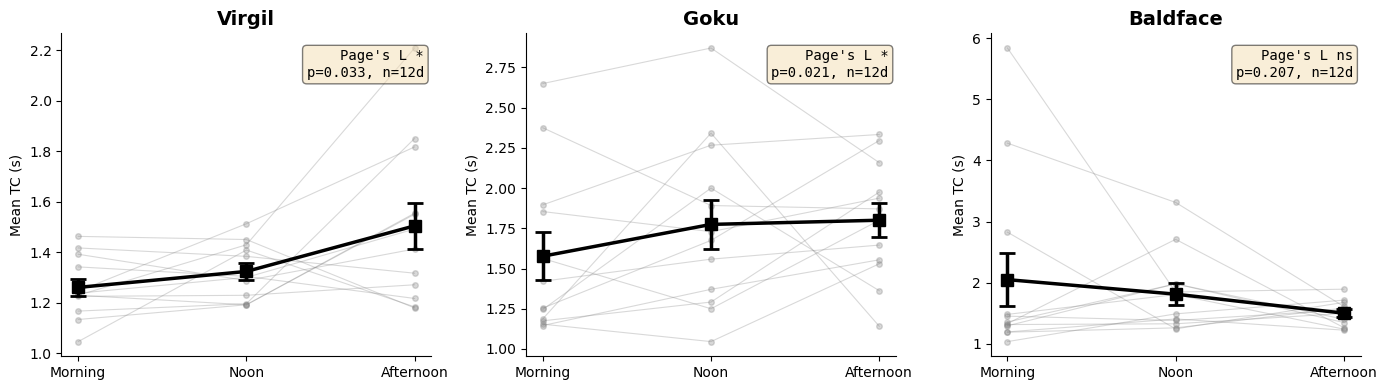

In [26]:
def plot_pvt_tc_trend(df, min_n=10, figsize=(14, 4)):
    """
    Spaghetti plot of daily Mean TC at PVT windows with Page's L test.
    """
    from scipy.stats import rankdata, norm
    
    def pages_L(mat):
        n, k = mat.shape
        ranks = np.zeros_like(mat, dtype=float)
        for i in range(n):
            ranks[i] = rankdata(mat[i])
        rank_sums = ranks.sum(axis=0)
        predicted = np.arange(1, k + 1)
        L = np.sum(predicted * rank_sums)
        E_L = n * k * (k + 1)**2 / 4
        Var_L = n * k**2 * (k + 1) * (k**2 - 1) / 144
        z = (L - E_L) / np.sqrt(Var_L)
        p = 1 - norm.cdf(z)
        return L, z, p
    
    subjects = df.columns.tolist()
    windows = {'Morning': 9, 'Noon': 12, 'Afternoon': 15}
    
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    
    n_subj = len(subjects)
    fig, axes = plt.subplots(1, n_subj, figsize=figsize, squeeze=False)
    x_pos = np.arange(3)
    wnames = list(windows.keys())
    
    for col, subj in enumerate(subjects):
        vals = df[subj].dropna()
        ax = axes[0, col]
        
        # Build daily means at each window
        rows = []
        for date in sorted(set(vals.index.date)):
            complete = True
            row = {}
            for wname, hr in windows.items():
                x = vals[(vals.index.date == date) & (vals.index.hour == hr)].values
                if len(x) < min_n:
                    complete = False
                    break
                row[wname] = np.mean(x)
            if complete:
                rows.append(row)
        
        dd = pd.DataFrame(rows)
        mat = dd[wnames].values
        
        # Spaghetti
        for d in range(len(mat)):
            ax.plot(x_pos, mat[d, :], '-o', color='gray',
                    alpha=0.3, markersize=4, linewidth=0.8)
        
        # Mean ± SEM
        means = mat.mean(axis=0)
        sems = mat.std(axis=0, ddof=1) / np.sqrt(len(mat))
        ax.errorbar(x_pos, means, yerr=sems, fmt='s-',
                    color='black', linewidth=2.5, markersize=8,
                    capsize=6, capthick=2, zorder=5)
        
        # Page's L
        L, z, p = pages_L(mat)
        p_sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        ax.text(0.98, 0.95,
                f"Page's L {p_sig}\np={p:.3f}, n={len(mat)}d",
                transform=ax.transAxes, ha='right', va='top',
                fontsize=10, fontfamily='monospace',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels(wnames)
        ax.set_ylabel('Mean TC (s)')
        ax.set_title(subj, fontsize=14, fontweight='bold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    return fig
fig = plot_pvt_tc_trend(alpha)

## Hidden Markov Model with Gamma Emission